# RAPIDS & Scanpy Single-Cell RNA-seq Workflow on PFC cells

Copyright (c) 2020, NVIDIA CORPORATION.

Licensed under the Apache License, Version 2.0 (the "License") you may not use this file except in compliance with the License. You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

This notebook demonstrates a single-cell RNA analysis workflow that begins with preprocessing a count matrix of size `(n_gene, n_cell)` and results in a visualization of the clustered cells for further analysis.

For demonstration purposes, we use a dataset of 1.3 M brain cells with Unified Virtual Memory to oversubscribe GPU memory.

## Import requirements

In [1]:
import numpy as np
import scanpy as sc
import anndata
import scipy.io
import scipy.sparse

import time
import os, wget


import cudf

from cuml.decomposition import PCA
from cuml.manifold import TSNE
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler

import cuml
import rapids_scanpy_funcs
import utils

import warnings
warnings.filterwarnings('ignore', 'Expected ')
warnings.simplefilter('ignore')
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import rmm

from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
cupy.cuda.set_allocator(rmm_cupy_allocator)
from scipy import sparse
import gc
import cupy as cp
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

We use the RAPIDS memory manager to enable Unified Virtual Memory management, which allows us to oversubscribe the GPU memory.

In [ ]:
import rmm
rmm.reinitialize(managed_memory=True)
from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
cupy.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
# Cell 1: GPUを固定（例: 2番GPU）
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# 任意: メモリ関連の安定化
os.environ["RMM_POOL_SIZE"] = "8GB"   # 例
os.environ["CUML_LOG_LEVEL"] = "info"

print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES = 3


## Input data

In the cell below, we provide the path to the sparse `.h5ad` file containing the count matrix to analyze. Please see the README for instructions on how to download the dataset we use here.

To run this notebook using your own dataset, please see the README for instructions to convert your own count matrix into this format. Then, replace the path in the cell below with the path to your generated `.h5ad` file.

In [3]:
import gc
import cupy as cp
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [ ]:

mtx_path=r"/data/human_MDD_PFC/GSE144136_GeneBarcodeMatrix_Annotated.mtx"
cell_name_path=r"/data/human_MDD_PFC/GSE144136_CellNames.csv"
gene_name_path=r"/data/human_MDD_PFC/GSE144136_GeneNames.csv"

genes = pd.read_csv(gene_name_path,index_col=0)
cells = pd.read_csv(cell_name_path,index_col=0)
adata=sc.read_mtx(mtx_path)
adata=adata.T
adata.obs_names = cells.x.values
adata.var_names = genes.x.values
adata.X=sparse.csr_matrix(adata.X)

celltype_df=pd.DataFrame(cells.x.str.split(".",expand=True))
barcode_df=celltype_df.iloc[:,1].str.split("_",expand=True)
barcode_df2=pd.concat([celltype_df.iloc[:,0],barcode_df],axis=1)
barcode_df2=barcode_df2.set_axis(["celltype","subject","case_control","batch","barcode"],axis="columns")
b_df3=barcode_df2.copy()
b_df3.index=adata.obs.index
obs_col=["celltype","subject","case_control","batch","barcode"]
adata.obs["label"]=b_df3["case_control"]
adata.write("/data/human_MDD_PFC/merged_data.h5ad")
#arr = scipy.io.mmread(mtx_path).tocsr()

In [ ]:
adata.write("/data/human_MDD_PFC/merged_data.h5ad")

In [ ]:
adata_control=adata[adata.obs["label"]=="Control"]
adata_suicide=adata[adata.obs["label"]=="Suicide"]

In [ ]:
adata_control.write("/data/human_MDD_PFC/merged_control_data.h5ad")
adata_suicide.write("/data/human_MDD_PFC/merged_suicide_data.h5ad")

preprocess_in_bulk
is_gpu=False: run full CPU preprocessing path (no cuDF/CuPy).
['CX3CR1', 'CLDN5', 'GLUL', 'NDRG2', 'PCDH15', 'PLP1', 'MBP', 'SATB2', 'SLC17A7', 'SLC17A6', 'GAD2', 'GAD1', 'SNAP25', 'HTR1A', 'HTR1B', 'HTR1D', 'HTR1E', 'HTR2A', 'HTR2B', 'HTR2C', 'HTR3A', 'HTR4', 'HTR5A', 'HTR6', 'HTR7', 'DRD1', 'DRD2', 'DRD3', 'DRD4', 'DRD5', 'HRH1', 'HRH2', 'HRH3', 'CHRM1', 'CHRM2', 'CHRM3', 'CHRM4', 'CHRM5', 'ADRA1A', 'ADRA1B', 'ADRA2A', 'ADRA2B', 'ADRA2C', 'ADRB1', 'ADRB2']
float32
Total Preprocessing time: 19.648499965667725
shape of adata: (35184, 29432)
perform PCA
10
UMAP
calc drug response
clz selective cells
# of clz selective cells: is_clz_selective
False    31217
True      3967
Name: count, dtype: int64


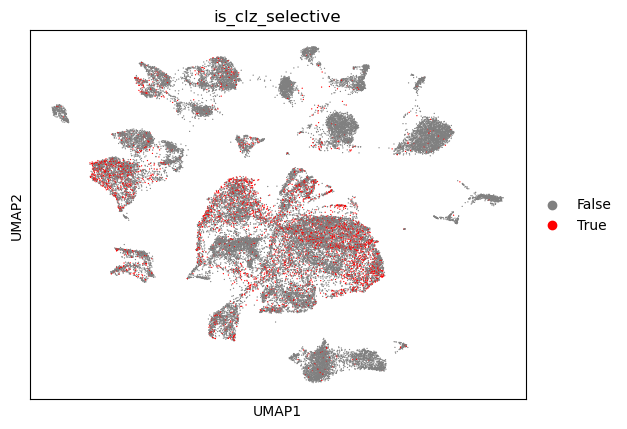

In [4]:
import calculation_tool as ct
file_path="/data/human_MDD_PFC/merged_control_data.h5ad"
#file_path="/data/human_MDD_PFC/merged_data.h5ad"
adata,GPCR_df=ct.preprocess_adata_in_bulk(file_path,label=None,is_gpu=False)
GPCR_df.to_csv("/data/human_MDD_PFC/control_data_GPCR_df.csv")

In [ ]:
import calculation_tool as ct
file_path="/data/human_MDD_PFC/merged_data.h5ad"
#file_path="/data/human_MDD_PFC/merged_data.h5ad"
adata,GPCR_df=ct.preprocess_adata_in_bulk(file_path,label=None,is_gpu=False)
GPCR_df.to_csv("/data/human_MDD_PFC/merged_data_GPCR_df.csv")

In [ ]:
GPCR_df.to_csv("/data/human_MDD_PFC/control_data_GPCR_df.csv")

Drug concentration: 0.001
clz selective cells
# of clz selective cells: is_clz_selective
False    34503
True       681
Name: count, dtype: int64


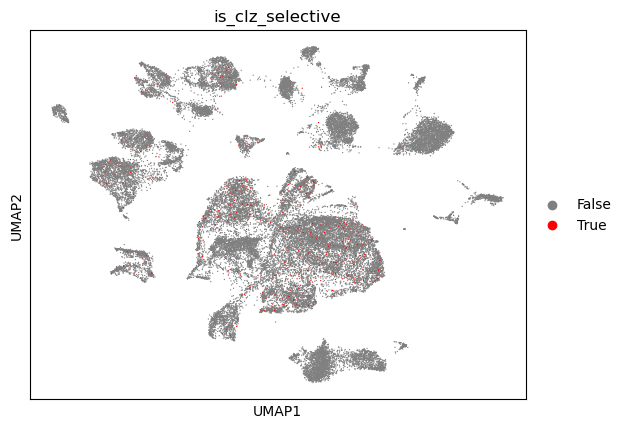

Drug concentration: 0.01
clz selective cells
# of clz selective cells: is_clz_selective
False    34503
True       681
Name: count, dtype: int64


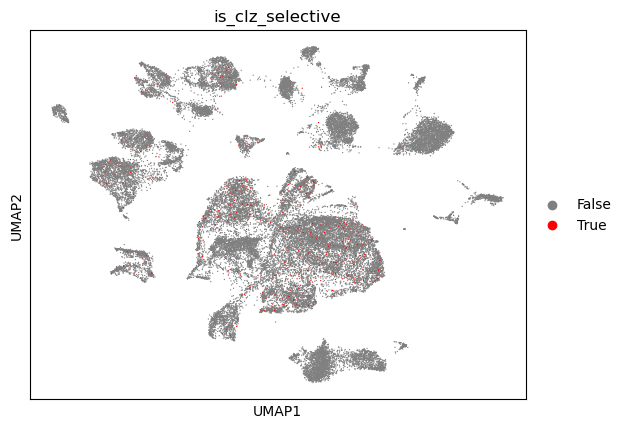

Drug concentration: 0.1
clz selective cells
# of clz selective cells: is_clz_selective
False    34503
True       681
Name: count, dtype: int64


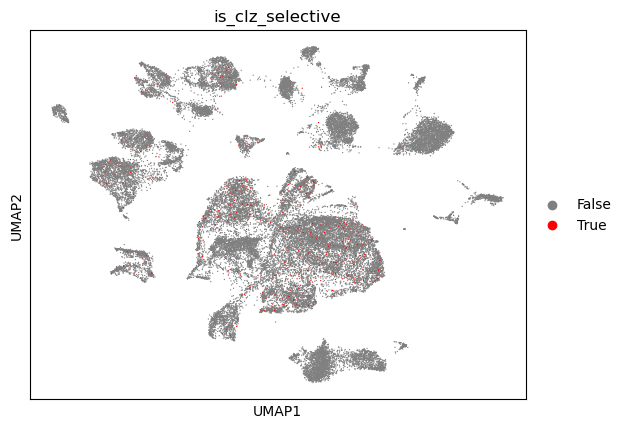

Drug concentration: 1
clz selective cells
# of clz selective cells: is_clz_selective
False    34481
True       703
Name: count, dtype: int64


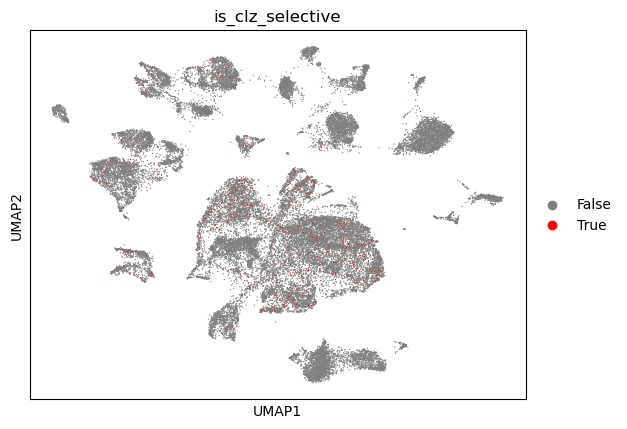

Drug concentration: 1.5848931924611136
clz selective cells
# of clz selective cells: is_clz_selective
False    34445
True       739
Name: count, dtype: int64


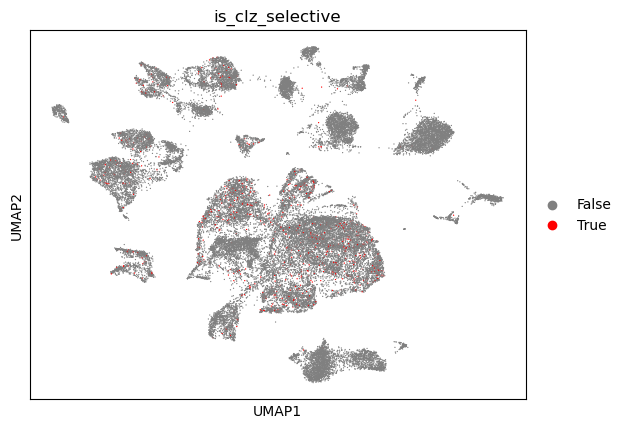

Drug concentration: 2.2387211385683394
clz selective cells
# of clz selective cells: is_clz_selective
False    34374
True       810
Name: count, dtype: int64


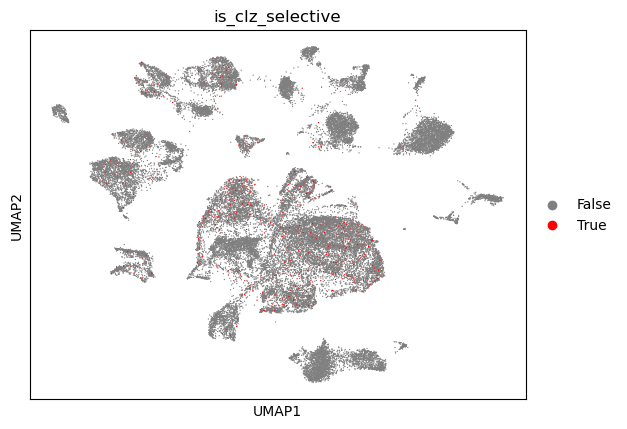

Drug concentration: 3.1622776601683795
clz selective cells
# of clz selective cells: is_clz_selective
False    33881
True      1303
Name: count, dtype: int64


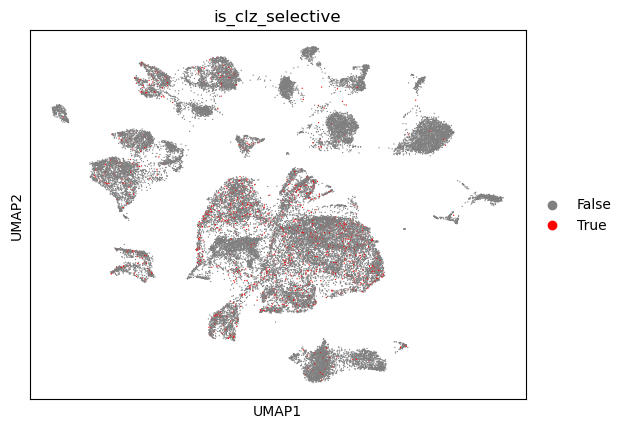

Drug concentration: 5.623413251903491
clz selective cells
# of clz selective cells: is_clz_selective
False    33804
True      1380
Name: count, dtype: int64


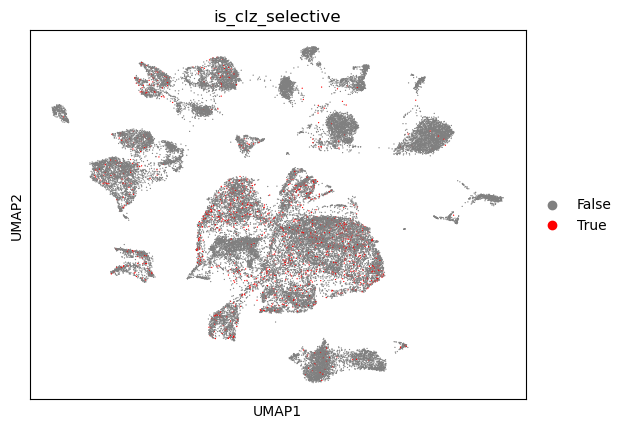

Drug concentration: 10
clz selective cells
# of clz selective cells: is_clz_selective
False    33608
True      1576
Name: count, dtype: int64


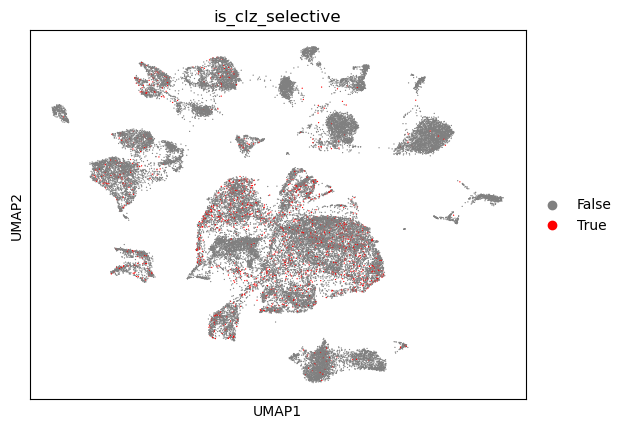

Drug concentration: 31.622776601683793
clz selective cells
# of clz selective cells: is_clz_selective
False    33234
True      1950
Name: count, dtype: int64


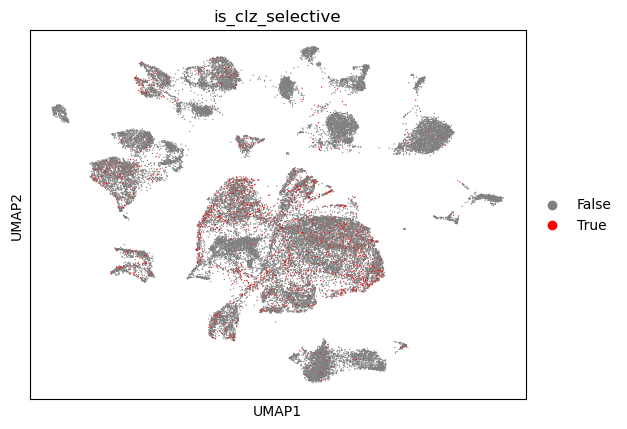

Drug concentration: 100
clz selective cells
# of clz selective cells: is_clz_selective
False    31518
True      3666
Name: count, dtype: int64


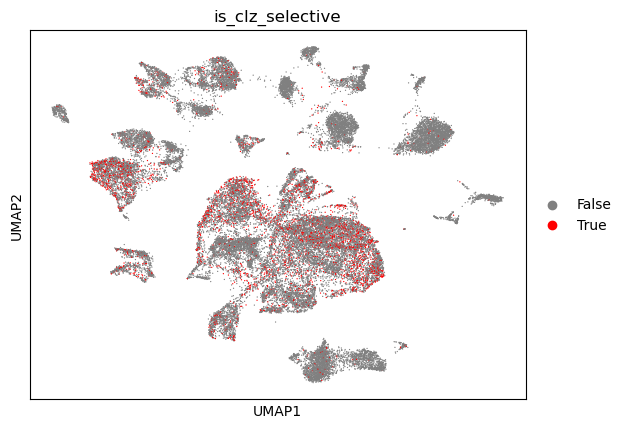

Drug concentration: 316.22776601683796
clz selective cells
# of clz selective cells: is_clz_selective
False    31252
True      3932
Name: count, dtype: int64


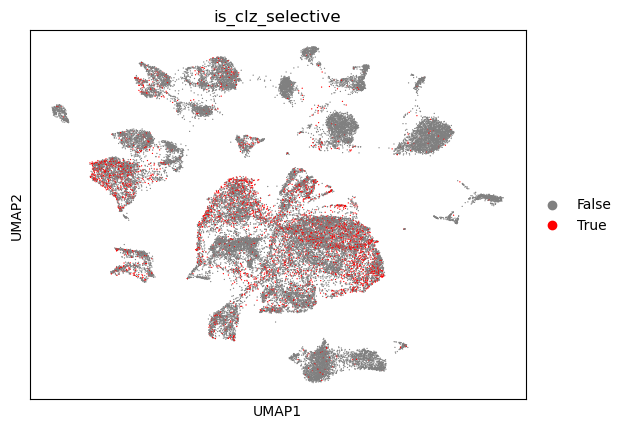

Drug concentration: 1000
clz selective cells
# of clz selective cells: is_clz_selective
False    31002
True      4182
Name: count, dtype: int64


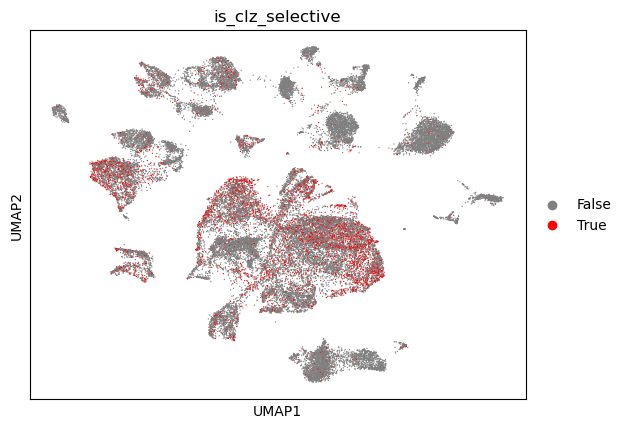

Drug concentration: 10000
clz selective cells
# of clz selective cells: is_clz_selective
False    31633
True      3551
Name: count, dtype: int64


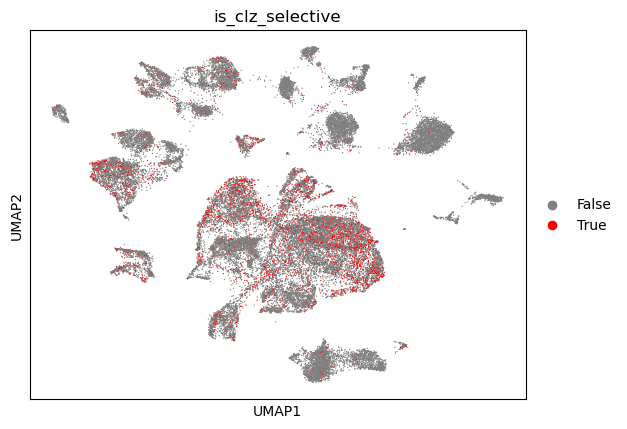

Drug concentration: 100000
clz selective cells
# of clz selective cells: is_clz_selective
False    32503
True      2681
Name: count, dtype: int64


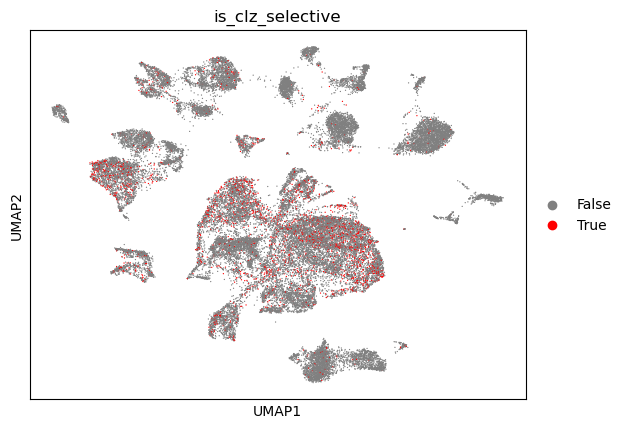

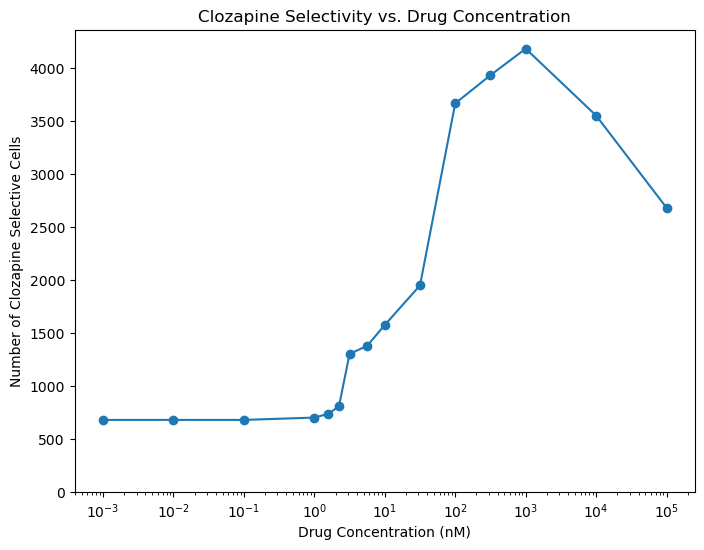

In [5]:
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()
params=ct.set_parameters_for_preprocess(GPCR_list)
import calculation_tool as ct
ct.drug_titeration(adata, GPCR_df, GPCR_type_df, drug_list, D_R_mtx)

In [ ]:
marker_genes_dict = {
    "Neuron": ["RBFOX3", "MAP2", "SLC17A7", "SATB2", "CUX2","BCL11B", "FEZF2","TLE4", "FOXP2","GAD1","PVALB","SST","VIP"],
    "Astrocyte": ["GFAP", "AQP4", "ALDH1L1"],
    "Oligodendrocyte": ["MBP", "MOG", "OLIG1", "OLIG2"],
    "Microglia": ["TMEM119", "AIF1", "CD68", "CX3CR1"],
    "Endothelial": ["CLDN5", "PECAM1", "VWF"],
    "OPC": ["PDGFRA", "CSPG4"],
    "Ependymal": ["FOXJ1"]
}
sc.pl.dotplot(adata, marker_genes_dict, "leiden")

In [ ]:
sc.pl.umap(adata, color=["HRH3_raw"])
sc.pl.umap(adata, color=["DRD1_raw"])
sc.pl.umap(adata, color=["HTR2A_raw"])
sc.pl.umap(adata, color=["HTR1E_raw"])
sc.pl.umap(adata, color=["HTR1A_raw"])

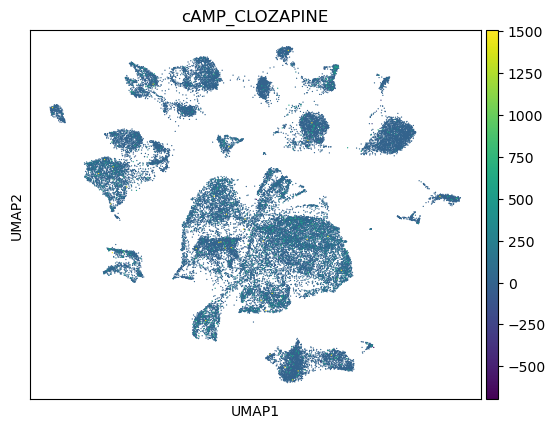

In [6]:
sc.pl.umap(adata, color=["cAMP_CLOZAPINE"])


In [7]:
GPCR_adata=anndata.AnnData(X=GPCR_df)
GPCR_adata_norm=sc.pp.normalize_total(GPCR_adata,target_sum=1e4,inplace=False)['X']
GPCR_adata_norm_df=pd.DataFrame(GPCR_adata_norm,columns=GPCR_adata.var.index)

clz selective cells
# of clz selective cells: is_clz_selective
False    31002
True      4182
Name: count, dtype: int64


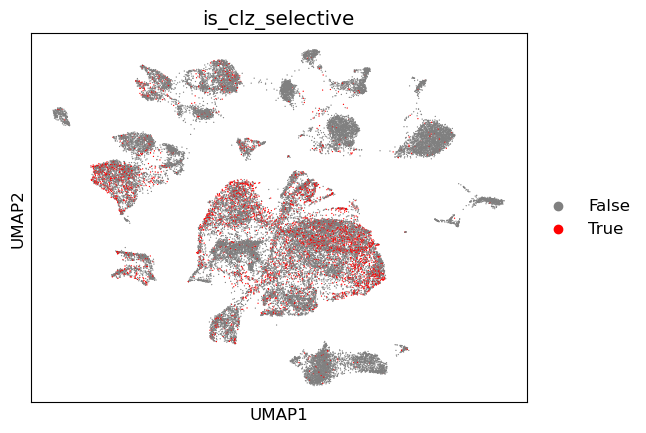

In [9]:
drug_conc=10**3
adata=ct.calc_drug_response(adata,GPCR_df,GPCR_type_df,drug_list,D_R_mtx,drug_conc)
selectivity_threshold=1.5
adata,num_clz_selective=ct.calc_clz_selective_cell(adata,drug_list,selectivity_threshold)

file_root, file_extension = os.path.splitext(file_path)
# Append '_processed' to the root and add the extension back
processed_file_path = f"{file_root}_processed{file_extension}"
adata.write(processed_file_path)

In [ ]:
#import calculation_tool as ct

drug_conc=10**3
results_df_sorted,all_responses=ct.sim_inhibit_pattern(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,n_pattern=10000)

In [ ]:
dir="/data/human_MDD_PFC"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses.csv"))

In [ ]:
ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

category
is_clz_selective
False    31002
True      4182
Name: count, dtype: int64


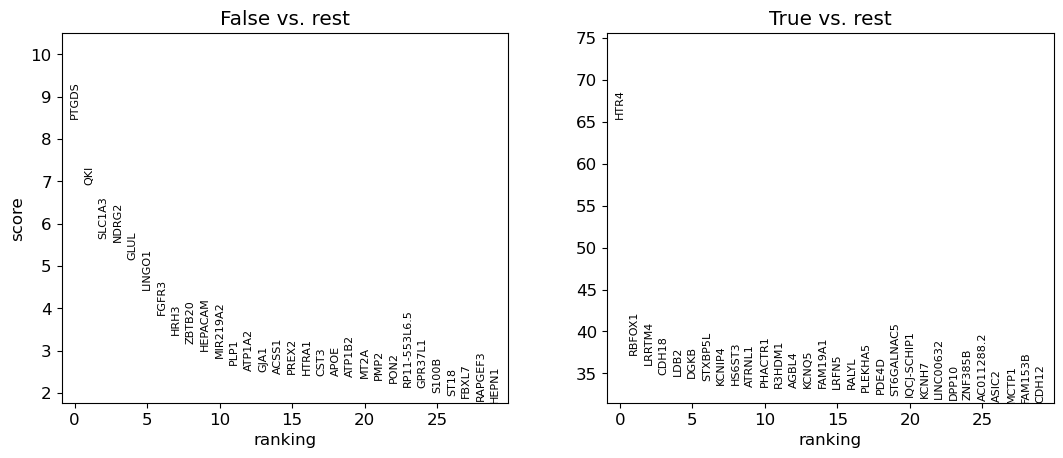

In [10]:
# is_clz_selective をカテゴリ型に変換
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype("category")

# 念のため確認
print(adata.obs["is_clz_selective"].dtype)
print(adata.obs["is_clz_selective"].value_counts())

# その後で rank_genes_groups
sc.tl.rank_genes_groups(adata, 'is_clz_selective', method='wilcoxon',layer="lognorm",
    use_raw=False,
    pts=True)
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)
df_deg = sc.get.rank_genes_groups_df(adata, group=None)
df_sig = df_deg[df_deg["pvals_adj"] < 0.05]
df_sig.to_csv("/data/human_MDD_PFC/significant_DEG_is_clz_selective.csv", index=False)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    output_pdf=None,
    title=None,
    figsize=(7, 6),
):
    """
    Scanpy sc.get.rank_genes_groups_df() の結果から volcano plot を作成する関数。

    Parameters
    ----------
    df_deg : pandas.DataFrame
        sc.get.rank_genes_groups_df(adata, group=None) の出力
    group : bool or str
        プロットする group。例: True, False, "True", "False"
    adj_p_cutoff : float
        adjusted p-value のカットオフ
    log2fc_cutoff : float
        absolute log2 fold change のカットオフ
    top_n_labels : int
        ラベル表示する有意遺伝子数
    output_pdf : str or None
        PDF保存先。Noneなら保存しない
    title : str or None
        プロットタイトル
    figsize : tuple
        図のサイズ
    """

    df = df_deg.copy()

    # groupで絞り込み
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
        df = df[df["group"] == str(group)].copy()

    if df.empty:
        raise ValueError(f"No rows found for group={group}")

    # logfoldchangesをlog2foldchangeとして扱う
    if "logfoldchanges" in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]
    elif "log2foldchange" not in df.columns:
        raise ValueError("df_deg must contain 'logfoldchanges' or 'log2foldchange'.")

    # adjusted p-value列
    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain 'pvals_adj' or 'adj_p_val'.")

    # p=0対策
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # 有意判定
    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["significant"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["significant"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df.loc[df["direction"] == "Not significant", "log2foldchange"],
        df.loc[df["direction"] == "Not significant", "minus_log10_adj_p"],
        s=8,
        alpha=0.4,
        color="lightgray",
        label="Not significant",
    )

    ax.scatter(
        df.loc[df["direction"] == "Up", "log2foldchange"],
        df.loc[df["direction"] == "Up", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="crimson",
        label="Up",
    )

    ax.scatter(
        df.loc[df["direction"] == "Down", "log2foldchange"],
        df.loc[df["direction"] == "Down", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="royalblue",
        label="Down",
    )

    # cutoff lines
    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # gene labels
    if "names" in df.columns and top_n_labels > 0:
        label_df = (
            df[df["significant"]]
            .sort_values(p_col)
            .head(top_n_labels)
        )

        for _, row in label_df.iterrows():
            ax.text(
                row["log2foldchange"],
                row["minus_log10_adj_p"],
                row["names"],
                fontsize=8,
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")

    if title is None:
        title = f"Volcano plot: group={group}"

    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_pdf is not None:
        plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
        print(f"Saved: {output_pdf}")

    plt.show()

    print("Total genes:", len(df))
    print("Significant genes:", df["significant"].sum())
    print("Up:", (df["direction"] == "Up").sum())
    print("Down:", (df["direction"] == "Down").sum())

    return df

Saved: /data/human_MDD_PFC/volcano_is_clz_selective_groupTrue.pdf


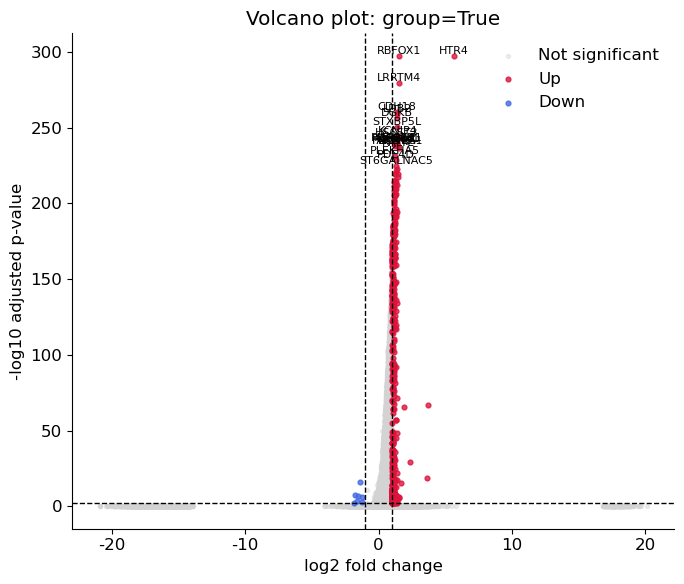

Total genes: 29432
Significant genes: 507
Up: 500
Down: 7


In [15]:
volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    output_pdf="/data/human_MDD_PFC/volcano_is_clz_selective_groupTrue.pdf",
)

In [ ]:
#clz_feature_analysis
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact


# ============================================================
# 0. Utility functions
# ============================================================

def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def _get_X(adata, layer="lognorm"):
    if layer is not None and layer in adata.layers:
        return adata.layers[layer]
    return adata.X


def _to_bool_mask(series, positive_value=True):
    """
    adata.obs["is_clz_selective"] が bool/category/string どれでも動くようにする
    """
    s = pd.Series(series).astype(str).str.lower()

    if isinstance(positive_value, bool):
        if positive_value:
            return s.isin(["true", "1", "yes", "y", "t"])
        else:
            return s.isin(["false", "0", "no", "n", "f"])
    else:
        return s == str(positive_value).lower()


def _match_genes(adata, genes):
    """
    adata.var_names が uppercase 前提でも、入力geneが小文字混じりでも拾えるようにする
    """
    var_map = {str(g).upper(): g for g in adata.var_names}
    matched = []
    missing = []

    for g in genes:
        key = str(g).upper()
        if key in var_map:
            matched.append(var_map[key])
        else:
            missing.append(g)

    return matched, missing


def _extract_expr(adata, genes, layer="lognorm"):
    matched, missing = _match_genes(adata, genes)
    if len(matched) == 0:
        return None, matched, missing

    X = _get_X(adata, layer=layer)
    idx = [adata.var_names.get_loc(g) for g in matched]
    mat = X[:, idx]

    return mat, matched, missing


def _mean_expr_per_cell(adata, genes, layer="lognorm"):
    mat, matched, missing = _extract_expr(adata, genes, layer=layer)
    if mat is None:
        return np.full(adata.n_obs, np.nan), matched, missing

    mean_expr = np.asarray(mat.mean(axis=1)).ravel()
    return mean_expr, matched, missing


def _bh_fdr(pvals):
    """
    Benjamini-Hochberg FDR
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.minimum(q, 1.0)

    out = np.empty_like(q)
    out[order] = q
    return out


def add_clz_group_column(
    adata,
    group_col="is_clz_selective",
    positive_value=True,
    out_col="clz_group",
):
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} is not found in adata.obs")

    mask = _to_bool_mask(adata.obs[group_col], positive_value=positive_value)

    adata.obs[out_col] = pd.Categorical(
        np.where(mask, "clz_selective", "non_selective"),
        categories=["non_selective", "clz_selective"],
    )

    print(adata.obs[out_col].value_counts())
    return mask


# ============================================================
# 1. Marker sets
# ============================================================

CELLTYPE_MARKERS = {
    "Excitatory": [
        "SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6",
        "TBR1", "RORB", "CUX2"
    ],
    "Inhibitory": [
        "GAD1", "GAD2", "SLC6A1", "DLX1", "DLX2"
    ],
    "Astrocyte": [
        "AQP4", "GFAP", "ALDH1L1", "SLC1A3", "GLUL", "NDRG2"
    ],
    "Oligodendrocyte": [
        "MBP", "PLP1", "MOG", "MOBP", "MAG"
    ],
    "OPC": [
        "PDGFRA", "CSPG4", "PCDH15", "OLIG1", "OLIG2"
    ],
    "Microglia": [
        "CX3CR1", "P2RY12", "C1QA", "AIF1", "TYROBP"
    ],
    "Endothelial": [
        "CLDN5", "FLT1", "PECAM1", "VWF"
    ],
}


LAYER_MARKERS = {
    "pan_excitatory": ["SLC17A7", "CAMK2A", "SATB2"],
    "L2_3_IT": ["CUX2", "LINC00507", "CALB1"],
    "L4_5_IT": ["RORB"],
    "L5_IT_PT": ["BCL11B", "FEZF2", "ETV1"],
    "L6_CT": ["FOXP2", "TLE4", "TBR1"],
    "inhibitory": ["GAD1", "GAD2", "SLC6A1"],
}


RECEPTOR_MARKERS = [
    "HTR1A", "HTR1B", "HRH3", "CHRM2",
    "HTR2A", "DRD2", "HRH1", "CHRM1", "CHRM3",
]


FUNCTIONAL_GENESETS = {
    "Synapse": [
        "SYN1", "SYN2", "SYN3", "SNAP25", "STX1A", "STXBP1",
        "SYT1", "VAMP2", "DLG4", "SHANK1", "SHANK2", "SHANK3"
    ],
    "Postsynaptic_density": [
        "DLG4", "DLGAP1", "DLGAP2", "HOMER1", "HOMER2",
        "SHANK1", "SHANK2", "SHANK3", "GRIN1", "GRIN2A", "GRIN2B"
    ],
    "Glutamatergic_synapse": [
        "SLC17A7", "SLC17A6", "GRIA1", "GRIA2", "GRIA3",
        "GRIN1", "GRIN2A", "GRIN2B", "GRID2"
    ],
    "Dendritic_spine_plasticity": [
        "BDNF", "NTRK2", "CAMK2A", "CAMK2B", "ARC", "FOS",
        "EGR1", "HOMER1", "DLG4", "RAC1", "CDC42", "PAK1"
    ],
    "cAMP_PKA_signaling": [
        "ADCY1", "ADCY5", "ADCY8", "PRKACA", "PRKACB",
        "PRKAR1A", "PRKAR2A", "CREB1", "PDE4A", "PDE4B", "PDE10A"
    ],
    "Activity_dependent_genes": [
        "FOS", "JUN", "JUNB", "EGR1", "EGR2", "ARC", "NPAS4", "BDNF"
    ],
}


# ============================================================
# 2. Module scores and inferred cell type
# ============================================================

def add_module_scores(
    adata,
    gene_sets,
    layer="lognorm",
    prefix="score_",
    verbose=True,
):
    """
    各gene setの平均lognorm発現をmodule scoreとしてadata.obsに追加
    """
    used_genes = {}

    for name, genes in gene_sets.items():
        score, matched, missing = _mean_expr_per_cell(adata, genes, layer=layer)
        col = f"{prefix}{name}"
        adata.obs[col] = score
        used_genes[name] = matched

        if verbose:
            print(f"{name}: used {len(matched)} genes -> {matched}")
            if len(matched) == 0:
                print(f"  WARNING: no genes found for {name}")

    return used_genes


def infer_celltype_by_marker_score(
    adata,
    marker_sets=CELLTYPE_MARKERS,
    layer="lognorm",
    out_col="celltype_inferred",
    min_score=0.02,
):
    """
    marker set平均発現が最大のcell typeを粗く割り当てる。
    既存のcelltype annotationがあるなら、そちらを使った方がよい。
    """
    add_module_scores(
        adata,
        marker_sets,
        layer=layer,
        prefix="score_celltype_",
        verbose=True,
    )

    score_cols = [f"score_celltype_{k}" for k in marker_sets.keys()]
    score_df = adata.obs[score_cols].copy()
    score_df.columns = list(marker_sets.keys())

    best_type = score_df.idxmax(axis=1)
    best_score = score_df.max(axis=1)

    best_type = best_type.astype(str)
    best_type[best_score < min_score] = "Unknown"

    adata.obs[out_col] = pd.Categorical(best_type)

    print(adata.obs[out_col].value_counts())
    return adata.obs[out_col]


# ============================================================
# 3. UMAP panels
# ============================================================

def save_umap_panels(
    adata,
    output_dir,
    layer="lognorm",
    extra_genes=None,
    basename="01_umap_clz_features.pdf",
):
    _ensure_dir(output_dir)

    colors = []

    for c in [
        "is_clz_selective",
        "clz_group",
        "cAMP_CLOZAPINE",
        "cAMP_clz_selectivity",
        "Ca_CLOZAPINE",
        "leiden",
        "celltype_inferred",
    ]:
        if c in adata.obs.columns:
            colors.append(c)

    if extra_genes is not None:
        matched, missing = _match_genes(adata, extra_genes)
        colors.extend(matched)
        if len(missing) > 0:
            print("UMAP missing genes:", missing)

    if len(colors) == 0:
        print("No UMAP features found.")
        return None

    sc.pl.umap(
        adata,
        color=colors,
        layer=layer if layer in adata.layers else None,
        use_raw=False,
        ncols=3,
        frameon=False,
        show=False,
    )

    out = os.path.join(output_dir, basename)
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    print("saved:", out)
    return out


# ============================================================
# 4. Cell type / cluster enrichment
# ============================================================

def compute_category_enrichment(
    adata,
    category_col,
    group_col="is_clz_selective",
    positive_value=True,
):
    """
    clz_selective cellsが各カテゴリーにenrichしているかをFisher exact testで評価
    """
    if category_col not in adata.obs.columns:
        raise ValueError(f"{category_col} is not found in adata.obs")

    mask = _to_bool_mask(adata.obs[group_col], positive_value=positive_value)
    category = adata.obs[category_col].astype(str)

    rows = []
    all_categories = sorted(category.dropna().unique())

    for cat in all_categories:
        in_cat = category == cat

        a = int((mask & in_cat).sum())
        b = int((~mask & in_cat).sum())
        c = int((mask & ~in_cat).sum())
        d = int((~mask & ~in_cat).sum())

        oddsratio, pval = fisher_exact([[a, b], [c, d]])

        # Haldane-Anscombe correction for CI
        aa, bb, cc, dd = a + 0.5, b + 0.5, c + 0.5, d + 0.5
        log_or = np.log((aa * dd) / (bb * cc))
        se = np.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)
        ci_low = np.exp(log_or - 1.96 * se)
        ci_high = np.exp(log_or + 1.96 * se)
        or_corr = np.exp(log_or)

        rows.append({
            "category": cat,
            "n_clz_selective_in_category": a,
            "n_nonselective_in_category": b,
            "n_clz_selective_outside": c,
            "n_nonselective_outside": d,
            "fraction_clz_selective_in_category": a / max(a + b, 1),
            "odds_ratio": or_corr,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "pval": pval,
        })

    df = pd.DataFrame(rows)
    df["qval"] = _bh_fdr(df["pval"].values)
    df = df.sort_values("odds_ratio", ascending=False)

    return df


def plot_enrichment_forest(
    df_enrich,
    output_pdf,
    title="Enrichment of clozapine-selective cells",
    top_n=None,
):
    df = df_enrich.copy()

    if top_n is not None:
        df = df.head(top_n)

    df = df.sort_values("odds_ratio", ascending=True)

    fig, ax = plt.subplots(figsize=(6, max(4, 0.35 * len(df))))

    y = np.arange(len(df))
    x = df["odds_ratio"].values
    xerr_low = x - df["ci_low"].values
    xerr_high = df["ci_high"].values - x

    ax.errorbar(
        x,
        y,
        xerr=[xerr_low, xerr_high],
        fmt="o",
        capsize=3,
    )

    ax.axvline(1, linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(df["category"])
    ax.set_xlabel("Odds ratio for clz_selective enrichment")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)


# ============================================================
# 5. Dot plot for marker genes
# ============================================================

def summarize_gene_expression_by_group(
    adata,
    genes,
    groupby="clz_group",
    layer="lognorm",
):
    matched, missing = _match_genes(adata, genes)
    if len(missing) > 0:
        print("missing genes:", missing)

    if len(matched) == 0:
        raise ValueError("No marker genes found in adata.var_names")

    X = _get_X(adata, layer=layer)

    groups = adata.obs[groupby].astype(str)
    group_order = list(pd.Categorical(adata.obs[groupby]).categories) \
        if isinstance(adata.obs[groupby].dtype, pd.CategoricalDtype) \
        else sorted(groups.unique())

    rows = []

    for gene in matched:
        idx = adata.var_names.get_loc(gene)
        x = X[:, idx]

        if sp.issparse(x):
            vals = np.asarray(x.toarray()).ravel()
        else:
            vals = np.asarray(x).ravel()

        for g in group_order:
            m = groups.values == str(g)
            rows.append({
                "gene": gene,
                "group": g,
                "mean_expr": float(np.mean(vals[m])),
                "pct_expr": float(np.mean(vals[m] > 0) * 100),
            })

    return pd.DataFrame(rows)


def plot_marker_dotplot(
    adata,
    genes,
    output_pdf,
    groupby="clz_group",
    layer="lognorm",
    title="Marker expression",
    dot_scale=4.0,
):
    df = summarize_gene_expression_by_group(
        adata,
        genes=genes,
        groupby=groupby,
        layer=layer,
    )

    genes_order = list(dict.fromkeys(df["gene"].tolist()))[::-1]
    groups_order = list(dict.fromkeys(df["group"].tolist()))

    x_map = {g: i for i, g in enumerate(groups_order)}
    y_map = {g: i for i, g in enumerate(genes_order)}

    fig, ax = plt.subplots(figsize=(max(4, 1.6 * len(groups_order)), max(4, 0.35 * len(genes_order))))

    sca = ax.scatter(
        df["group"].map(x_map),
        df["gene"].map(y_map),
        s=df["pct_expr"] * dot_scale + 1,
        c=df["mean_expr"],
        alpha=0.85,
    )

    ax.set_xticks(range(len(groups_order)))
    ax.set_xticklabels(groups_order, rotation=45, ha="right")
    ax.set_yticks(range(len(genes_order)))
    ax.set_yticklabels(genes_order)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

    cbar = plt.colorbar(sca, ax=ax)
    cbar.set_label("Mean expression")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    csv_out = output_pdf.replace(".pdf", ".csv")
    df.to_csv(csv_out, index=False)

    print("saved:", output_pdf)
    print("saved:", csv_out)

    return df


# ============================================================
# 6. Violin plot for receptor / cAMP features
# ============================================================

def plot_feature_violin_by_group(
    adata,
    features,
    output_pdf,
    groupby="clz_group",
    max_points=1500,
):
    features = [f for f in features if f in adata.obs.columns]
    if len(features) == 0:
        print("No features found for violin plot.")
        return None

    groups = list(pd.Categorical(adata.obs[groupby]).categories) \
        if isinstance(adata.obs[groupby].dtype, pd.CategoricalDtype) \
        else sorted(adata.obs[groupby].astype(str).unique())

    n = len(features)
    fig, axes = plt.subplots(
        1,
        n,
        figsize=(max(4 * n, 5), 4),
        squeeze=False,
    )
    axes = axes.ravel()

    rng = np.random.default_rng(0)

    for ax, feat in zip(axes, features):
        data = []
        for g in groups:
            vals = adata.obs.loc[adata.obs[groupby].astype(str) == str(g), feat].astype(float).values
            vals = vals[np.isfinite(vals)]
            data.append(vals)

        ax.violinplot(data, showmeans=False, showmedians=True, showextrema=False)

        for i, vals in enumerate(data, start=1):
            if len(vals) > max_points:
                vals_plot = rng.choice(vals, size=max_points, replace=False)
            else:
                vals_plot = vals

            jitter = rng.normal(loc=i, scale=0.04, size=len(vals_plot))
            ax.scatter(jitter, vals_plot, s=3, alpha=0.15)

        ax.set_xticks(np.arange(1, len(groups) + 1))
        ax.set_xticklabels(groups, rotation=45, ha="right")
        ax.set_title(feat)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return output_pdf


# ============================================================
# 7. DEG and volcano plot
# ============================================================

def run_deg_clz_selective(
    adata,
    output_dir,
    groupby="clz_group",
    case="clz_selective",
    control="non_selective",
    layer="lognorm",
    method="wilcoxon",
):
    _ensure_dir(output_dir)

    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=[case],
        reference=control,
        method=method,
        layer=layer if layer in adata.layers else None,
        use_raw=False,
        pts=True,
    )

    df_deg = sc.get.rank_genes_groups_df(adata, group=case)
    df_deg["log2foldchange"] = df_deg["logfoldchanges"]

    out_csv = os.path.join(output_dir, "05_DEG_clz_selective_vs_nonselective.csv")
    df_deg.to_csv(out_csv, index=False)
    print("saved:", out_csv)

    return df_deg


def plot_volcano_from_deg(
    df_deg,
    output_pdf,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    title="clz_selective vs non_selective",
    label_genes=None,
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    p_col = "pvals_adj"

    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[df["significant"] & (df["log2foldchange"] > 0), "direction"] = "Up"
    df.loc[df["significant"] & (df["log2foldchange"] < 0), "direction"] = "Down"

    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.35),
        ("Up", 12, 0.8),
        ("Down", 12, 0.8),
    ]:
        d = df[df["direction"] == direction]
        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(-np.log10(adj_p_cutoff), linestyle="--", linewidth=1)
    ax.axvline(log2fc_cutoff, linestyle="--", linewidth=1)
    ax.axvline(-log2fc_cutoff, linestyle="--", linewidth=1)

    if label_genes is not None:
        label_set = {g.upper() for g in label_genes}
        label_df = df[df["names"].astype(str).str.upper().isin(label_set)].copy()
        label_df = label_df.sort_values(p_col)
    else:
        label_df = df[df["significant"]].sort_values(p_col).head(top_n_labels)

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            row["names"],
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return df


# ============================================================
# 8. Gene set enrichment from DEG
# ============================================================

def gene_set_enrichment_from_deg(
    df_deg,
    gene_sets,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    direction="up",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    df["gene_upper"] = df["names"].astype(str).str.upper()

    background = set(df["gene_upper"])
    if direction == "up":
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "gene_upper"
        ])
    elif direction == "down":
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] <= -log2fc_cutoff),
            "gene_upper"
        ])
    else:
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"].abs() >= log2fc_cutoff),
            "gene_upper"
        ])

    rows = []

    for name, genes in gene_sets.items():
        gene_set = {g.upper() for g in genes} & background

        if len(gene_set) == 0:
            continue

        a = len(sig & gene_set)
        b = len(gene_set - sig)
        c = len(sig - gene_set)
        d = len(background - sig - gene_set)

        oddsratio, pval = fisher_exact([[a, b], [c, d]])

        aa, bb, cc, dd = a + 0.5, b + 0.5, c + 0.5, d + 0.5
        or_corr = (aa * dd) / (bb * cc)

        rows.append({
            "gene_set": name,
            "n_gene_set_in_background": len(gene_set),
            "n_sig_in_gene_set": a,
            "n_sig_total": len(sig),
            "odds_ratio": or_corr,
            "pval": pval,
            "genes_used": ",".join(sorted(gene_set)),
            "sig_genes_in_set": ",".join(sorted(sig & gene_set)),
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["qval"] = _bh_fdr(out["pval"].values)
        out = out.sort_values("odds_ratio", ascending=False)

    return out


def plot_gene_set_enrichment(
    df_enrich,
    output_pdf,
    title="Gene set enrichment",
):
    if df_enrich is None or len(df_enrich) == 0:
        print("No enrichment result to plot.")
        return None

    df = df_enrich.copy().sort_values("odds_ratio", ascending=True)
    df["minus_log10_q"] = -np.log10(df["qval"].replace(0, 1e-300))

    fig, ax = plt.subplots(figsize=(6, max(4, 0.45 * len(df))))

    y = np.arange(len(df))
    sca = ax.scatter(
        df["odds_ratio"],
        y,
        s=df["n_sig_in_gene_set"] * 25 + 20,
        c=df["minus_log10_q"],
        alpha=0.85,
    )

    ax.axvline(1, linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(df["gene_set"])
    ax.set_xlabel("Odds ratio")
    ax.set_title(title)

    cbar = plt.colorbar(sca, ax=ax)
    cbar.set_label("-log10 FDR")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return output_pdf

# ============================================================
# 10. GO / Reactome / Hallmark enrichment analysis
# ============================================================

def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    """
    GSEA prerank用のrankingを作成。
    基本は scanpy rank_genes_groups の scores を使う。
    """

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = pd.to_numeric(df["scores"], errors="coerce")
    else:
        p = pd.to_numeric(df["pvals_adj"], errors="coerce").replace(0, 1e-300)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated gene対策
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO / Reactome / Hallmark の ranked GSEA。
    論文用の主解析として使いやすい。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running GSEA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            pre_res = gp.prerank(
                rnk=rnk,
                gene_sets=gene_sets,
                min_size=min_size,
                max_size=max_size,
                permutation_num=permutation_num,
                outdir=None,
                seed=0,
                threads=threads,
                verbose=True,
            )

            res = pre_res.res2d.copy()

            # gseapyのversion差対策
            if "Term" not in res.columns:
                res = res.reset_index().rename(columns={"index": "Term"})

            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] GSEA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    positive_only=True,
    title="Top GSEA terms",
):
    """
    GSEA結果をNESのbar plotとしてPDF保存。
    positive_only=Trueなら clz_selective側でenrichedなtermだけ表示。
    """

    if df_gsea is None or len(df_gsea) == 0:
        print("No GSEA results.")
        return None

    df = df_gsea.copy()

    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else None
    nes_col = "NES" if "NES" in df.columns else None
    term_col = "Term" if "Term" in df.columns else None

    if fdr_col is None or nes_col is None or term_col is None:
        print("GSEA columns not found. columns=", df.columns.tolist())
        return None

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")
    df = df.dropna(subset=[fdr_col, nes_col])

    if positive_only:
        df = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()
    else:
        df = df[df[fdr_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant GSEA terms.")
        return None

    df_plot = df.sort_values(fdr_col).head(top_n).copy()
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


def run_ora_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    GO / Reactome ORA。
    有意上昇遺伝子だけを使うので Supplement向き。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = (
        df["names"]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    up_csv = os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv")
    pd.DataFrame({"gene": up_genes}).to_csv(up_csv, index=False)
    print("saved:", up_csv)

    if len(up_genes) == 0:
        print("[WARN] No upregulated genes for ORA.")
        return pd.DataFrame()

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            enr = gp.enrich(
                gene_list=up_genes,
                gene_sets=gene_sets,
                background=background,
                outdir=None,
                verbose=True,
            )

            res = enr.results.copy()
            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] ORA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_ora_terms(
    df_ora,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    title="Top ORA terms",
):
    """
    ORA結果を -log10 adjusted p-value のbar plotとしてPDF保存。
    """

    if df_ora is None or len(df_ora) == 0:
        print("No ORA results.")
        return None

    df = df_ora.copy()

    term_col = "Term" if "Term" in df.columns else None
    p_col = "Adjusted P-value" if "Adjusted P-value" in df.columns else None

    if term_col is None or p_col is None:
        print("ORA columns not found. columns=", df.columns.tolist())
        return None

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df = df.dropna(subset=[p_col])
    df = df[df[p_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant ORA terms.")
        return None

    df["minus_log10_fdr"] = -np.log10(df[p_col].replace(0, 1e-300))
    df_plot = df.sort_values(p_col).head(top_n).copy()
    df_plot = df_plot.sort_values("minus_log10_fdr", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot["minus_log10_fdr"])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


# ============================================================
# 9. Main runner
# ============================================================

def run_clz_feature_analysis(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,

    # GO/GSEA options
    run_go_gsea=True,
    run_go_ora=True,
    organism="Human",
    gsea_libraries=None,
    ora_libraries=None,
    gsea_permutation_num=1000,
    gsea_threads=4,
):
    """
    preprocess_adata_in_bulk後のadataを入れるだけで、
    クロザピン反応細胞の特徴解析figureを一通り出す。

    追加：
    - GO / Reactome / Hallmark ranked GSEA
    - GO / Reactome ORA
    """

    _ensure_dir(output_dir)

    # ---- group column ----
    add_clz_group_column(
        adata,
        group_col=group_col,
        positive_value=positive_value,
        out_col="clz_group",
    )

    # ---- cell type inference if needed ----
    if celltype_col is None:
        infer_celltype_by_marker_score(
            adata,
            marker_sets=CELLTYPE_MARKERS,
            layer=layer,
            out_col="celltype_inferred",
        )
        celltype_col = "celltype_inferred"
    else:
        if celltype_col not in adata.obs.columns:
            raise ValueError(f"{celltype_col} is not found in adata.obs")

    # ---- module scores ----
    add_module_scores(
        adata,
        LAYER_MARKERS,
        layer=layer,
        prefix="score_layer_",
        verbose=True,
    )

    add_module_scores(
        adata,
        FUNCTIONAL_GENESETS,
        layer=layer,
        prefix="score_function_",
        verbose=True,
    )

    # ---- UMAP ----
    save_umap_panels(
        adata,
        output_dir=output_dir,
        layer=layer,
        extra_genes=[
            "SLC17A7", "GAD1", "GAD2", "SATB2",
            "CUX2", "RORB", "BCL11B", "FEZF2", "FOXP2",
            "HTR1A", "HRH3", "CHRM2",
        ],
        basename="01_umap_clz_features.pdf",
    )

    # ---- enrichment by inferred/annotated cell type ----
    df_celltype_enrich = compute_category_enrichment(
        adata,
        category_col=celltype_col,
        group_col=group_col,
        positive_value=positive_value,
    )

    celltype_csv = os.path.join(output_dir, "02_celltype_enrichment.csv")
    df_celltype_enrich.to_csv(celltype_csv, index=False)
    print("saved:", celltype_csv)

    plot_enrichment_forest(
        df_celltype_enrich,
        output_pdf=os.path.join(output_dir, "02_celltype_enrichment.pdf"),
        title=f"Enrichment by {celltype_col}",
    )

    # ---- enrichment by leiden cluster ----
    if "leiden" in adata.obs.columns:
        df_leiden_enrich = compute_category_enrichment(
            adata,
            category_col="leiden",
            group_col=group_col,
            positive_value=positive_value,
        )

        leiden_csv = os.path.join(output_dir, "02b_leiden_enrichment.csv")
        df_leiden_enrich.to_csv(leiden_csv, index=False)
        print("saved:", leiden_csv)

        plot_enrichment_forest(
            df_leiden_enrich,
            output_pdf=os.path.join(output_dir, "02b_leiden_enrichment.pdf"),
            title="Enrichment by Leiden cluster",
        )
    else:
        df_leiden_enrich = None

    # ---- layer marker dot plot ----
    layer_gene_list = []
    for genes in LAYER_MARKERS.values():
        layer_gene_list.extend(genes)
    layer_gene_list = list(dict.fromkeys(layer_gene_list))

    df_layer_dot = plot_marker_dotplot(
        adata,
        genes=layer_gene_list,
        output_pdf=os.path.join(output_dir, "03_layer_marker_dotplot.pdf"),
        groupby="clz_group",
        layer=layer,
        title="Layer / neuronal marker expression",
    )

    # ---- receptor marker dot plot ----
    df_receptor_dot = plot_marker_dotplot(
        adata,
        genes=RECEPTOR_MARKERS,
        output_pdf=os.path.join(output_dir, "04_receptor_marker_dotplot.pdf"),
        groupby="clz_group",
        layer=layer,
        title="Receptor marker expression",
    )

    # ---- cAMP / receptor raw feature violin ----
    candidate_features = [
        "cAMP_CLOZAPINE",
        "cAMP_clz_selectivity",
        "cAMP_mean_other_than_czp",
        "Ca_CLOZAPINE",
        "HTR1A_raw",
        "HTR1B_raw",
        "HRH3_raw",
        "CHRM2_raw",
        "HTR2A_raw",
        "DRD2_raw",
        "HRH1_raw",
        "CHRM1_raw",
        "CHRM3_raw",
    ]

    plot_feature_violin_by_group(
        adata,
        features=candidate_features,
        output_pdf=os.path.join(output_dir, "04b_camp_receptor_feature_violin.pdf"),
        groupby="clz_group",
    )

    # ---- DEG ----
    df_deg = run_deg_clz_selective(
        adata,
        output_dir=output_dir,
        groupby="clz_group",
        case="clz_selective",
        control="non_selective",
        layer=layer,
        method="wilcoxon",
    )

    # ---- volcano ----
    label_genes = (
        layer_gene_list
        + RECEPTOR_MARKERS
        + FUNCTIONAL_GENESETS["Synapse"]
        + FUNCTIONAL_GENESETS["Dendritic_spine_plasticity"]
        + FUNCTIONAL_GENESETS["cAMP_PKA_signaling"]
    )

    volcano_df = plot_volcano_from_deg(
        df_deg,
        output_pdf=os.path.join(output_dir, "06_volcano_clz_selective_vs_nonselective.pdf"),
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
        top_n_labels=25,
        title="clz_selective vs non_selective",
        label_genes=label_genes,
    )

    volcano_csv = os.path.join(output_dir, "06_volcano_plot_table.csv")
    volcano_df.to_csv(volcano_csv, index=False)
    print("saved:", volcano_csv)

    # ---- curated functional gene set enrichment ----
    df_func_enrich = gene_set_enrichment_from_deg(
        df_deg,
        gene_sets=FUNCTIONAL_GENESETS,
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
        direction="up",
    )

    func_csv = os.path.join(output_dir, "07_functional_gene_set_enrichment_up.csv")
    df_func_enrich.to_csv(func_csv, index=False)
    print("saved:", func_csv)

    plot_gene_set_enrichment(
        df_func_enrich,
        output_pdf=os.path.join(output_dir, "07_functional_gene_set_enrichment_up.pdf"),
        title="Curated gene set enrichment in clz_selective up genes",
    )

    # ========================================================
    # 追加：GO / Reactome / Hallmark GSEA
    # ========================================================

    if run_go_gsea:
        if gsea_libraries is None:
            gsea_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
                "MSigDB_Hallmark_2020",
            ]

        df_gsea = run_gsea_prerank_go_reactome_from_deg(
            df_deg,
            output_dir=output_dir,
            prefix="all_cells_clz_selective_vs_nonselective",
            organism=organism,
            libraries=gsea_libraries,
            min_size=5,
            max_size=500,
            permutation_num=gsea_permutation_num,
            threads=gsea_threads,
        )

        top_gsea = plot_top_gsea_terms(
            df_gsea,
            output_pdf=os.path.join(output_dir, "08_GO_Reactome_GSEA_top_positive_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            positive_only=True,
            title="All cells: GO/Reactome GSEA enriched in clz_selective cells",
        )
    else:
        df_gsea = None
        top_gsea = None

    # ========================================================
    # 追加：GO / Reactome ORA
    # ========================================================

    if run_go_ora:
        if ora_libraries is None:
            ora_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
            ]

        df_ora = run_ora_go_reactome_from_deg(
            df_deg,
            output_dir=output_dir,
            prefix="all_cells_clz_selective_vs_nonselective",
            organism=organism,
            libraries=ora_libraries,
            adj_p_cutoff=adj_p_cutoff,
            log2fc_cutoff=log2fc_cutoff,
        )

        top_ora = plot_top_ora_terms(
            df_ora,
            output_pdf=os.path.join(output_dir, "09_GO_Reactome_ORA_top_up_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            title="All cells: GO/Reactome ORA enriched in clz_selective up genes",
        )
    else:
        df_ora = None
        top_ora = None

    results = {
        "adata": adata,
        "celltype_enrichment": df_celltype_enrich,
        "leiden_enrichment": df_leiden_enrich,
        "layer_dotplot": df_layer_dot,
        "receptor_dotplot": df_receptor_dot,
        "deg": df_deg,
        "volcano": volcano_df,
        "functional_enrichment": df_func_enrich,
        "go_reactome_gsea": df_gsea,
        "go_reactome_gsea_top": top_gsea,
        "go_reactome_ora": df_ora,
        "go_reactome_ora_top": top_ora,
    }

    return results

In [28]:
results = run_clz_feature_analysis(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,   # 既存のcelltype列があれば "cell_type" などに変更
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
)

clz_group
non_selective    31002
clz_selective     4182
Name: count, dtype: int64
Excitatory: used 8 genes -> ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6', 'TBR1', 'RORB', 'CUX2']
Inhibitory: used 5 genes -> ['GAD1', 'GAD2', 'SLC6A1', 'DLX1', 'DLX2']
Astrocyte: used 6 genes -> ['AQP4', 'GFAP', 'ALDH1L1', 'SLC1A3', 'GLUL', 'NDRG2']
Oligodendrocyte: used 5 genes -> ['MBP', 'PLP1', 'MOG', 'MOBP', 'MAG']
OPC: used 5 genes -> ['PDGFRA', 'CSPG4', 'PCDH15', 'OLIG1', 'OLIG2']
Microglia: used 5 genes -> ['CX3CR1', 'P2RY12', 'C1QA', 'AIF1', 'TYROBP']
Endothelial: used 4 genes -> ['CLDN5', 'FLT1', 'PECAM1', 'VWF']
celltype_inferred
Excitatory         17656
Inhibitory          5662
Oligodendrocyte     4130
Astrocyte           3707
OPC                 2065
Unknown             1443
Endothelial          294
Microglia            227
Name: count, dtype: int64
pan_excitatory: used 3 genes -> ['SLC17A7', 'CAMK2A', 'SATB2']
L2_3_IT: used 3 genes -> ['CUX2', 'LINC00507', 'CALB1']
L4_5_IT: used 1 gen

2026-05-30 07:00:45,815 [WARNING] Duplicated values found in preranked stats: 14.58% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 07:00:45,816 [INFO] Parsing data files for GSEA.............................
2026-05-30 07:00:45,937 [INFO] 0166 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 07:00:45,939 [INFO] 5240 gene_sets used for further statistical testing.....
2026-05-30 07:00:45,939 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 07:03:18,519 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_GSEA_GO_Biological_Process_2023.csv
Running GSEA: GO_Cellular_Component_2023


2026-05-30 07:03:22,108 [WARNING] Duplicated values found in preranked stats: 14.58% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 07:03:22,109 [INFO] Parsing data files for GSEA.............................
2026-05-30 07:03:22,151 [INFO] 0029 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 07:03:22,152 [INFO] 0443 gene_sets used for further statistical testing.....
2026-05-30 07:03:22,153 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 07:03:36,176 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_GSEA_GO_Cellular_Component_2023.csv
Running GSEA: GO_Molecular_Function_2023


...

saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_GO_Cellular_Component_2023.csv
Running ORA: GO_Molecular_Function_2023


2026-05-30 07:05:30,374 [INFO] Input dict object named with gs_ind_0
2026-05-30 07:05:30,376 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 07:05:30,696 [INFO] Done.


saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_GO_Molecular_Function_2023.csv
Running ORA: Reactome_2022


2026-05-30 07:05:34,754 [INFO] Input dict object named with gs_ind_0
2026-05-30 07:05:34,755 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 07:05:35,275 [INFO] Done.


saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_Reactome_2022.csv
saved: /data/human_MDD_PFC/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_all_libraries.csv
saved: /data/human_MDD_PFC/clz_feature_analysis/09_GO_Reactome_ORA_top_up_terms.pdf
saved: /data/human_MDD_PFC/clz_feature_analysis/09_GO_Reactome_ORA_top_up_terms.csv


In [19]:
!pip install gseapy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Group counts:
_clz_group
FALSE    31002
TRUE      4182
Name: count, dtype: int64
adata.layers['lognorm'] already exists.
Found genes: {'5HT1A': 'HTR1A', 'M2': 'CHRM2', 'H3': 'HRH3'}
stats_df:


,gene_label,gene,group_FALSE,group_TRUE,n_FALSE,n_TRUE,mean_FALSE_lognorm,mean_TRUE_lognorm,delta_mean_TRUE_minus_FALSE,median_FALSE_lognorm,...,delta_median_TRUE_minus_FALSE,pct_expr_FALSE,pct_expr_TRUE,delta_pct_TRUE_minus_FALSE,mannwhitneyu_stat,p_value_expression,fisher_odds_ratio_positive,p_value_positive_fraction,q_value_expression_FDR,q_value_positive_fraction_FDR
0,5HT1A,HTR1A,FALSE,TRUE,31002,4182,0.000108,0.000467,0.000359,0.0,...,0.0,0.009677,0.047824,0.038147,64849910.0,5.207552e-02,4.944019,1.105809e-01,5.207552e-02,1.105809e-01
1,M2,CHRM2,FALSE,TRUE,31002,4182,0.139684,0.139575,-0.000110,0.0,...,0.0,9.299400,12.721186,3.421786,66713992.5,2.459469e-09,1.421589,1.237276e-11,3.689203e-09,1.855913e-11
2,H3,HRH3,FALSE,TRUE,31002,4182,0.135733,0.059949,-0.075784,0.0,...,0.0,8.686536,5.714969,-2.971567,62747439.0,2.056252e-12,0.637176,9.643832e-12,6.168757e-12,1.855913e-11


summary_pct:


,gene_label,gene,group,pct_expressing,mean_lognorm_expression,median_lognorm_expression,n_cells
0,5HT1A,HTR1A,FALSE,0.009677,0.000108,0.0,31002
1,5HT1A,HTR1A,TRUE,0.047824,0.000467,0.0,4182
2,H3,HRH3,FALSE,8.686536,0.135733,0.0,31002
3,H3,HRH3,TRUE,5.714969,0.059949,0.0,4182
4,M2,CHRM2,FALSE,9.299400,0.139684,0.0,31002
5,M2,CHRM2,TRUE,12.721186,0.139575,0.0,4182


saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf
saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf
saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/receptor_positive_fraction_TRUE_vs_FALSE.pdf
saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/receptor_delta_mean_expression_TRUE_minus_FALSE.pdf
saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf
saved: /data/human_MDD_PFC/clz_receptor_expression_analysis/scanpy_violin_receptors_TRUE_vs_FALSE.pdf
Done.
All outputs saved to: /data/human_MDD_PFC/clz_receptor_expression_analysis


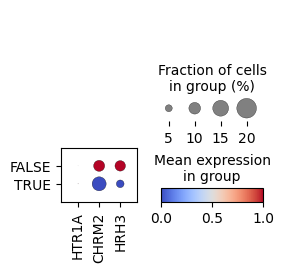

In [17]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================

# OUTDIRが既に定義されていればそれを使う
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/human_MDD_PFC/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

GROUPBY = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12

gene_aliases = {
    "5HT1A": ["Htr1a", "HTR1A"],
    "M2":    ["Chrm2", "CHRM2"],
    "H3":    ["Hrh3", "HRH3"],
}

# 比較順
GROUP_ORDER = ["FALSE", "TRUE"]
GROUP_LABELS = {
    "FALSE": "Non-responsive",
    "TRUE": "Clozapine-responsive",
}


# =========================
# helper functions
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def ensure_clz_group(adata, groupby=GROUPBY):
    """
    TRUE/FALSEを安定して扱うための列を作る。
    """
    adata.obs["_clz_group"] = (
        adata.obs[groupby]
        .astype(str)
        .str.upper()
        .replace({
            "1": "TRUE",
            "0": "FALSE",
            "TRUE": "TRUE",
            "FALSE": "FALSE",
            "True": "TRUE",
            "False": "FALSE",
        })
        .astype("category")
    )

    print("Group counts:")
    print(adata.obs["_clz_group"].value_counts())

    valid = adata.obs["_clz_group"].isin(["TRUE", "FALSE"])
    return valid


def ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm layerがなければraw_countsから作成。
    """
    if layer in adata.layers:
        print(f"adata.layers['{layer}'] already exists.")
        return

    if raw_layer not in adata.layers:
        raise ValueError(
            f"adata.layers['{layer}'] not found, and "
            f"adata.layers['{raw_layer}'] is also missing."
        )

    print(f"Creating adata.layers['{layer}'] from adata.layers['{raw_layer}']...")

    adata.layers[layer] = adata.layers[raw_layer].copy()

    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
        layer=layer
    )
    sc.pp.log1p(
        adata,
        layer=layer
    )

    adata.layers[layer] = adata.layers[layer].astype("float32")
    print("done.")


def resolve_gene_aliases(adata, gene_aliases):
    """
    mouse/human両対応。
    adata.var_names上の実際のgene名を探す。
    大文字小文字の違いも吸収する。
    """
    var_map = {str(g).upper(): str(g) for g in adata.var_names}

    found_genes = {}
    missing = {}

    for label, aliases in gene_aliases.items():
        hit = None

        for g in aliases:
            gu = str(g).upper()
            if gu in var_map:
                hit = var_map[gu]
                break

        if hit is None:
            missing[label] = aliases
            print(f"Warning: {label} not found. tried: {aliases}")
        else:
            found_genes[label] = hit

    print("Found genes:", found_genes)

    if len(found_genes) == 0:
        raise ValueError("No target genes were found in adata.var_names.")

    return found_genes, missing


def get_expr_vector(adata, gene, layer):
    """
    指定layerからgene expression vectorを取得。
    """
    idx = adata.var_names.get_loc(gene)
    x = adata.layers[layer][:, idx]

    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x).ravel()


def add_gene_vectors_to_obs(adata, found_genes, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm expressionとraw positiveをobsに追加。
    """
    for label, gene in found_genes.items():
        expr = get_expr_vector(adata, gene, layer=layer)
        adata.obs[f"{label}_gene"] = gene
        adata.obs[f"{label}_lognorm"] = expr

        if raw_layer in adata.layers:
            raw = get_expr_vector(adata, gene, layer=raw_layer)
            adata.obs[f"{label}_raw"] = raw
            adata.obs[f"{label}_positive"] = raw > 0
        else:
            adata.obs[f"{label}_positive"] = expr > 0

    return adata


def build_long_expression_df(adata, found_genes, valid_mask):
    records = []

    for label, gene in found_genes.items():
        tmp = pd.DataFrame({
            "cell": adata.obs_names[valid_mask],
            "group": adata.obs.loc[valid_mask, "_clz_group"].astype(str).values,
            "gene_label": label,
            "gene": gene,
            "lognorm_expression": adata.obs.loc[valid_mask, f"{label}_lognorm"].values,
            "expressed": adata.obs.loc[valid_mask, f"{label}_positive"].values,
        })

        if f"{label}_raw" in adata.obs.columns:
            tmp["raw_counts"] = adata.obs.loc[valid_mask, f"{label}_raw"].values

        records.append(tmp)

    return pd.concat(records, axis=0, ignore_index=True)


def compute_stats(df_expr):
    stats = []

    groups = [g for g in GROUP_ORDER if g in df_expr["group"].unique()]
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups, got: {groups}")

    g_false, g_true = groups[0], groups[1]

    for label in df_expr["gene_label"].unique():
        d = df_expr[df_expr["gene_label"] == label].copy()

        x_false = d.loc[d["group"] == g_false, "lognorm_expression"].values
        x_true = d.loc[d["group"] == g_true, "lognorm_expression"].values

        u, p_expr = mannwhitneyu(
            x_true,
            x_false,
            alternative="two-sided"
        )

        pos_false = d.loc[d["group"] == g_false, "expressed"].values.astype(bool)
        pos_true = d.loc[d["group"] == g_true, "expressed"].values.astype(bool)

        table = [
            [pos_true.sum(), len(pos_true) - pos_true.sum()],
            [pos_false.sum(), len(pos_false) - pos_false.sum()],
        ]

        odds, p_pos = fisher_exact(table)

        stats.append({
            "gene_label": label,
            "gene": d["gene"].iloc[0],

            "group_FALSE": g_false,
            "group_TRUE": g_true,

            "n_FALSE": len(x_false),
            "n_TRUE": len(x_true),

            "mean_FALSE_lognorm": np.mean(x_false),
            "mean_TRUE_lognorm": np.mean(x_true),
            "delta_mean_TRUE_minus_FALSE": np.mean(x_true) - np.mean(x_false),

            "median_FALSE_lognorm": np.median(x_false),
            "median_TRUE_lognorm": np.median(x_true),
            "delta_median_TRUE_minus_FALSE": np.median(x_true) - np.median(x_false),

            "pct_expr_FALSE": np.mean(pos_false) * 100,
            "pct_expr_TRUE": np.mean(pos_true) * 100,
            "delta_pct_TRUE_minus_FALSE": (np.mean(pos_true) - np.mean(pos_false)) * 100,

            "mannwhitneyu_stat": u,
            "p_value_expression": p_expr,

            "fisher_odds_ratio_positive": odds,
            "p_value_positive_fraction": p_pos,
        })

    stats_df = pd.DataFrame(stats)

    stats_df["q_value_expression_FDR"] = multipletests(
        stats_df["p_value_expression"],
        method="fdr_bh"
    )[1]

    stats_df["q_value_positive_fraction_FDR"] = multipletests(
        stats_df["p_value_positive_fraction"],
        method="fdr_bh"
    )[1]

    return stats_df


# =========================
# plotting functions
# =========================

def plot_lognorm_violin(df_expr, stats_df):
    genes = list(df_expr["gene_label"].unique())
    n_genes = len(genes)

    fig, ax = plt.subplots(figsize=(max(5.5, 1.4 * n_genes), 4.5))

    positions = []
    data = []
    xticks = []

    width_offset = 0.18

    for i, label in enumerate(genes):
        for j, group in enumerate(GROUP_ORDER):
            vals = df_expr.loc[
                (df_expr["gene_label"] == label) &
                (df_expr["group"] == group),
                "lognorm_expression"
            ].values

            pos = i + (-width_offset if group == "FALSE" else width_offset)
            positions.append(pos)
            data.append(vals)

        xticks.append(i)

    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.28,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # jitter points
    rng = np.random.default_rng(0)
    for pos, vals in zip(positions, data):
        if len(vals) > 3000:
            vals_plot = rng.choice(vals, size=3000, replace=False)
        else:
            vals_plot = vals

        jitter = rng.normal(loc=pos, scale=0.025, size=len(vals_plot))
        ax.scatter(
            jitter,
            vals_plot,
            s=4,
            alpha=0.25,
            linewidths=0,
        )

    ax.set_xticks(xticks)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Receptor mRNA expression")

    # 凡例用ダミー
    ax.scatter([], [], label="Non-responsive", alpha=0.7)
    ax.scatter([], [], label="Clozapine-responsive", alpha=0.7)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))

    # p値アノテーション
    y_max = df_expr["lognorm_expression"].max()
    y_text = y_max * 1.05 if y_max > 0 else 0.1

    for i, label in enumerate(genes):
        row = stats_df[stats_df["gene_label"] == label].iloc[0]
        ax.text(
            i,
            y_text,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf")


def plot_mean_expression_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["mean_FALSE_lognorm"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["mean_TRUE_lognorm"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Mean expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Mean receptor expression")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["mean_FALSE_lognorm"], row["mean_TRUE_lognorm"])
        ax.text(
            i,
            ymax * 1.05 if ymax > 0 else 0.05,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf")


def plot_positive_fraction_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["pct_expr_FALSE"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["pct_expr_TRUE"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("% expressing cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.set_title("Fraction of receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["pct_expr_FALSE"], row["pct_expr_TRUE"])
        ax.text(
            i,
            min(ymax + 4, 98),
            f"q={row['q_value_positive_fraction_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_positive_fraction_TRUE_vs_FALSE.pdf")


def plot_delta_summary(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x,
        stats_df["delta_mean_TRUE_minus_FALSE"],
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Delta mean expression\nTRUE - FALSE")
    ax.set_title("Expression enrichment in clozapine-responsive cells")

    for i, row in stats_df.iterrows():
        y = row["delta_mean_TRUE_minus_FALSE"]
        ax.text(
            i,
            y,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_delta_mean_expression_TRUE_minus_FALSE.pdf")


def plot_scanpy_dotplot(adata, genes_for_plot):
    """
    Scanpy dotplotもPDF保存。
    """
    dp = sc.pl.dotplot(
        adata,
        var_names=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        standard_scale="var",
        color_map="coolwarm",
        return_fig=True,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf")
    dp.savefig(path)
    print("saved:", path)


def plot_scanpy_violin(adata, genes_for_plot):
    """
    Scanpy violinもPDF保存。
    """
    sc.pl.violin(
        adata,
        keys=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        stripplot=False,
        jitter=False,
        rotation=45,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_violin_receptors_TRUE_vs_FALSE.pdf")
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print("saved:", path)


# =========================
# main
# =========================

valid_mask = ensure_clz_group(adata, GROUPBY)
ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER)

found_genes, missing_genes = resolve_gene_aliases(adata, gene_aliases)

adata = add_gene_vectors_to_obs(
    adata,
    found_genes,
    layer=LAYER,
    raw_layer=RAW_LAYER,
)

df_expr = build_long_expression_df(
    adata,
    found_genes,
    valid_mask=valid_mask,
)

df_expr = df_expr[df_expr["group"].isin(GROUP_ORDER)].copy()
df_expr["group"] = pd.Categorical(
    df_expr["group"],
    categories=GROUP_ORDER,
    ordered=True,
)

stats_df = compute_stats(df_expr)

# =========================
# save tables
# =========================

df_expr.to_csv(
    os.path.join(OUTDIR, "receptor_expression_long_format.csv"),
    index=False,
)

stats_df.to_csv(
    os.path.join(OUTDIR, "receptor_expression_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

summary_pct = (
    df_expr
    .groupby(["gene_label", "gene", "group"], observed=True)
    .agg(
        pct_expressing=("expressed", lambda x: np.mean(x) * 100),
        mean_lognorm_expression=("lognorm_expression", "mean"),
        median_lognorm_expression=("lognorm_expression", "median"),
        n_cells=("lognorm_expression", "size"),
    )
    .reset_index()
)

summary_pct.to_csv(
    os.path.join(OUTDIR, "receptor_expression_summary_by_group.csv"),
    index=False,
)

print("stats_df:")
display(stats_df)

print("summary_pct:")
display(summary_pct)

# =========================
# save figures as Illustrator-editable PDF
# =========================

genes_for_plot = list(found_genes.values())

plot_lognorm_violin(df_expr, stats_df)
plot_mean_expression_bar(stats_df)
plot_positive_fraction_bar(stats_df)
plot_delta_summary(stats_df)

plot_scanpy_dotplot(adata[valid_mask].copy(), genes_for_plot)
plot_scanpy_violin(adata[valid_mask].copy(), genes_for_plot)

print("Done.")
print("All outputs saved to:", OUTDIR)

excitatory内比較 + GO/GSEA解析コード

In [22]:
#excitatory内比較 + GO/GSEA解析コード
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt


# ============================================================
# basic utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def bool_mask_from_obs(series, positive_value=True):
    s = pd.Series(series).astype(str).str.lower()

    if isinstance(positive_value, bool):
        if positive_value:
            return s.isin(["true", "1", "yes", "y", "t"])
        else:
            return s.isin(["false", "0", "no", "n", "f"])

    return s == str(positive_value).lower()


def match_genes(adata, genes):
    var_map = {str(g).upper(): g for g in adata.var_names}
    matched = []
    missing = []

    for g in genes:
        key = str(g).upper()
        if key in var_map:
            matched.append(var_map[key])
        else:
            missing.append(g)

    return matched, missing


def get_gene_score(adata, genes, layer="lognorm"):
    matched, missing = match_genes(adata, genes)

    if len(matched) == 0:
        print("No matched genes:", genes)
        return np.full(adata.n_obs, np.nan), matched, missing

    X = adata.layers[layer] if layer in adata.layers else adata.X
    idx = [adata.var_names.get_loc(g) for g in matched]
    mat = X[:, idx]

    score = np.asarray(mat.mean(axis=1)).ravel()
    return score, matched, missing


def add_clz_group(adata, group_col="is_clz_selective", positive_value=True):
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} not found in adata.obs")

    mask = bool_mask_from_obs(adata.obs[group_col], positive_value=positive_value)

    adata.obs["clz_group"] = pd.Categorical(
        np.where(mask, "clz_selective", "non_selective"),
        categories=["non_selective", "clz_selective"],
    )

    print(adata.obs["clz_group"].value_counts())
    return mask


# ============================================================
# excitatory subset
# ============================================================

def subset_excitatory_cells(
    adata,
    celltype_col=None,
    excitatory_labels=("Excitatory", "Excitatory neuron", "excitatory", "ExN", "Glutamatergic"),
    layer="lognorm",
    out_col="is_excitatory_marker_inferred",
):
    """
    celltype annotationがある場合はそれを優先。
    ない場合は SLC17A7/SLC17A6/CAMK2A/SATB2 > GAD1/GAD2/SLC6A1 で粗く推定。
    """

    if celltype_col is not None and celltype_col in adata.obs.columns:
        labels = set([str(x) for x in excitatory_labels])
        exc_mask = adata.obs[celltype_col].astype(str).isin(labels).values
        print(f"Use existing annotation: {celltype_col}")
        print("n excitatory:", int(exc_mask.sum()))
        return adata[exc_mask].copy()

    exc_markers = ["SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6"]
    inh_markers = ["GAD1", "GAD2", "SLC6A1"]
    neuron_markers = ["SNAP25", "SYT1", "RBFOX3"]

    exc_score, exc_used, exc_missing = get_gene_score(adata, exc_markers, layer=layer)
    inh_score, inh_used, inh_missing = get_gene_score(adata, inh_markers, layer=layer)
    neuron_score, neuron_used, neuron_missing = get_gene_score(adata, neuron_markers, layer=layer)

    adata.obs["score_excitatory_marker"] = exc_score
    adata.obs["score_inhibitory_marker"] = inh_score
    adata.obs["score_neuronal_marker"] = neuron_score

    # 粗い判定：
    # excitatory markerが発現し、inhibitory markerより高く、neuronal markerもある程度ある
    exc_mask = (
        np.isfinite(exc_score)
        & np.isfinite(inh_score)
        & (exc_score > 0)
        & (exc_score > inh_score)
    )

    # SNAP25等が取れていればneuronal filterも追加
    if np.isfinite(neuron_score).sum() > 0:
        exc_mask = exc_mask & (neuron_score > 0)

    adata.obs[out_col] = pd.Categorical(exc_mask)

    print("Excitatory markers used:", exc_used)
    print("Inhibitory markers used:", inh_used)
    print("Neuronal markers used:", neuron_used)
    print("n excitatory inferred:", int(exc_mask.sum()))
    print("fraction excitatory inferred:", float(exc_mask.mean()))

    return adata[exc_mask].copy()


# ============================================================
# DEG within excitatory cells
# ============================================================

def run_deg_within_excitatory(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    celltype_col=None,
    excitatory_labels=("Excitatory", "Excitatory neuron", "excitatory", "ExN", "Glutamatergic"),
    layer="lognorm",
    min_cells_per_group=20,
    method="wilcoxon",
):
    ensure_dir(output_dir)

    # 全体adataにclz_groupを作る
    add_clz_group(
        adata,
        group_col=group_col,
        positive_value=positive_value,
    )

    # excitatory subset
    adata_exc = subset_excitatory_cells(
        adata,
        celltype_col=celltype_col,
        excitatory_labels=excitatory_labels,
        layer=layer,
    )

    # subset後にcategoryを整える
    add_clz_group(
        adata_exc,
        group_col=group_col,
        positive_value=positive_value,
    )

    counts = adata_exc.obs["clz_group"].value_counts()
    print("Excitatory subset group counts:")
    print(counts)

    if counts.get("clz_selective", 0) < min_cells_per_group:
        raise ValueError("Too few clz_selective excitatory cells.")
    if counts.get("non_selective", 0) < min_cells_per_group:
        raise ValueError("Too few non_selective excitatory cells.")

    # DEG
    sc.tl.rank_genes_groups(
        adata_exc,
        groupby="clz_group",
        groups=["clz_selective"],
        reference="non_selective",
        method=method,
        layer=layer if layer in adata_exc.layers else None,
        use_raw=False,
        pts=True,
    )

    df_deg_exc = sc.get.rank_genes_groups_df(adata_exc, group="clz_selective")
    df_deg_exc["log2foldchange"] = df_deg_exc["logfoldchanges"]

    deg_csv = os.path.join(output_dir, "DEG_excitatory_clz_selective_vs_nonselective.csv")
    df_deg_exc.to_csv(deg_csv, index=False)
    print("saved:", deg_csv)

    adata_out = os.path.join(output_dir, "adata_excitatory_subset.h5ad")
    adata_exc.write(adata_out)
    print("saved:", adata_out)

    return adata_exc, df_deg_exc


# ============================================================
# volcano plot
# ============================================================

def plot_volcano_deg(
    df_deg,
    output_pdf,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=25,
    label_genes=None,
    title="DEG volcano",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    p_col = "pvals_adj"
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[df["significant"] & (df["log2foldchange"] > 0), "direction"] = "Up"
    df.loc[df["significant"] & (df["log2foldchange"] < 0), "direction"] = "Down"

    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.35),
        ("Up", 12, 0.8),
        ("Down", 12, 0.8),
    ]:
        d = df[df["direction"] == direction]
        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(-np.log10(adj_p_cutoff), linestyle="--", linewidth=1)
    ax.axvline(log2fc_cutoff, linestyle="--", linewidth=1)
    ax.axvline(-log2fc_cutoff, linestyle="--", linewidth=1)

    if label_genes is not None:
        label_set = {g.upper() for g in label_genes}
        label_df = df[df["names"].astype(str).str.upper().isin(label_set)].copy()
        label_df = label_df.sort_values(p_col)
    else:
        label_df = df[df["significant"]].sort_values(p_col).head(top_n_labels)

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            row["names"],
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return df

In [23]:
#Go reactome enrichment
def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = df["scores"].astype(float)
    else:
        p = df["pvals_adj"].replace(0, 1e-300).astype(float)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated genesがあれば絶対値が大きいものを残す
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO/Reactome ranked GSEA.
    Enrichr/MSigDB系のライブラリをgseapy経由で取得して使う。
    """

    import gseapy as gp

    ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running prerank GSEA:", lib)

        gene_sets = gp.get_library(
            name=lib,
            organism=organism,
        )

        pre_res = gp.prerank(
            rnk=rnk,
            gene_sets=gene_sets,
            min_size=min_size,
            max_size=max_size,
            permutation_num=permutation_num,
            outdir=None,
            seed=0,
            threads=threads,
            verbose=True,
        )

        res = pre_res.res2d.copy()
        res["library"] = lib

        out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
        res.to_csv(out_csv, index=False)
        print("saved:", out_csv)

        all_results.append(res)

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=20,
    title="Top enriched pathways",
):
    df = df_gsea.copy()

    # gseapyのversionで列名が微妙に違う可能性に対応
    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else "fdr"
    nes_col = "NES" if "NES" in df.columns else "nes"
    term_col = "Term" if "Term" in df.columns else "term"

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")

    df = df.dropna(subset=[fdr_col, nes_col])

    # positive NESだけ。clz_selectiveで上がる方向
    df_pos = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()

    if len(df_pos) == 0:
        print("No significant positive GSEA terms.")
        return None

    df_pos["minus_log10_fdr"] = -np.log10(df_pos[fdr_col].replace(0, 1e-300))
    df_plot = df_pos.sort_values(fdr_col).head(top_n)
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    return df_plot


def run_ora_go_reactome(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    Over-representation analysis。
    有意上昇遺伝子だけを使うのでSupplement向き。
    """

    import gseapy as gp

    ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = df["names"].astype(str).str.upper().dropna().unique().tolist()

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    up_csv = os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv")
    pd.DataFrame({"gene": up_genes}).to_csv(up_csv, index=False)
    print("saved:", up_csv)

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        gene_sets = gp.get_library(
            name=lib,
            organism=organism,
        )

        enr = gp.enrich(
            gene_list=up_genes,
            gene_sets=gene_sets,
            background=background,
            outdir=None,
            verbose=True,
        )

        res = enr.results.copy()
        res["library"] = lib

        out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
        res.to_csv(out_csv, index=False)
        print("saved:", out_csv)

        all_results.append(res)

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all

In [24]:
outdir = "/data/human_MDD_PFC/clz_feature_analysis_excitatory"

adata_exc, df_deg_exc = run_deg_within_excitatory(
    adata,
    output_dir=outdir,
    group_col="is_clz_selective",
    positive_value=True,
    celltype_col=None,   # 既存annotationがなければNone
    layer="lognorm",
    min_cells_per_group=20,
)

clz_group
non_selective    31002
clz_selective     4182
Name: count, dtype: int64
Excitatory markers used: ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6']
Inhibitory markers used: ['GAD1', 'GAD2', 'SLC6A1']
Neuronal markers used: ['SNAP25', 'SYT1', 'RBFOX3']
n excitatory inferred: 19859
fraction excitatory inferred: 0.5644326966803093
clz_group
non_selective    16619
clz_selective     3240
Name: count, dtype: int64
Excitatory subset group counts:
clz_group
non_selective    16619
clz_selective     3240
Name: count, dtype: int64
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/DEG_excitatory_clz_selective_vs_nonselective.csv
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/adata_excitatory_subset.h5ad


In [25]:
# ============================================================
# Add-on: excitatory-only clozapine feature analysis
# Requires the previous run_clz_feature_analysis() code cell
# ============================================================

import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


# ----------------------------
# 0. Check required functions
# ----------------------------

def _check_clz_feature_helpers():
    required = [
        "_ensure_dir",
        "_mean_expr_per_cell",
        "add_clz_group_column",
        "run_clz_feature_analysis",
    ]
    missing = [x for x in required if x not in globals()]
    if len(missing) > 0:
        raise NameError(
            "先に前回の clz_feature_analysis 関数群を実行してね。"
            f" Missing: {missing}"
        )


# ----------------------------
# 1. Excitatory marker sets
# ----------------------------

EXCITATORY_POSITIVE_MARKERS = [
    "SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6"
]

INHIBITORY_NEGATIVE_MARKERS = [
    "GAD1", "GAD2", "SLC6A1"
]

NEURONAL_MARKERS = [
    "SNAP25", "SYT1", "RBFOX3"
]

EXCITATORY_SUBTYPE_MARKERS = {
    "L2_3_IT": ["CUX2", "LINC00507", "CALB1", "SATB2"],
    "L4_5_IT": ["RORB"],
    "L5_IT_PT": ["BCL11B", "FEZF2", "ETV1"],
    "L6_CT": ["FOXP2", "TLE4", "TBR1"],
}


# ----------------------------
# 2. Subset excitatory cells
# ----------------------------

def subset_excitatory_cells_for_clz_analysis(
    adata,
    celltype_col=None,
    excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),
    layer="lognorm",
    min_exc_score=0.02,
    min_exc_cells=50,
):
    """
    既存celltype annotationがある場合はそれを優先。
    なければ marker score で excitatory-like cells を抽出。
    """

    adata = adata.copy()

    # ---- annotation-based subset ----
    if celltype_col is not None and celltype_col in adata.obs.columns:
        labels = adata.obs[celltype_col].astype(str).str.lower()

        exc_mask = np.zeros(adata.n_obs, dtype=bool)

        for pat in excitatory_label_patterns:
            pat = str(pat).lower()
            exc_mask |= labels.str.contains(pat, regex=False).values

        print(f"Use annotation-based excitatory subset: {celltype_col}")
        print("n excitatory by annotation:", int(exc_mask.sum()))

        if exc_mask.sum() >= min_exc_cells:
            adata.obs["is_excitatory_for_analysis"] = pd.Categorical(exc_mask)
            return adata[exc_mask].copy()

        print("[WARN] Too few excitatory cells by annotation. Fallback to marker-based inference.")

    # ---- marker-based subset ----
    exc_score, exc_used, exc_missing = _mean_expr_per_cell(
        adata,
        EXCITATORY_POSITIVE_MARKERS,
        layer=layer,
    )
    inh_score, inh_used, inh_missing = _mean_expr_per_cell(
        adata,
        INHIBITORY_NEGATIVE_MARKERS,
        layer=layer,
    )
    neuronal_score, neuronal_used, neuronal_missing = _mean_expr_per_cell(
        adata,
        NEURONAL_MARKERS,
        layer=layer,
    )

    adata.obs["score_excitatory_marker"] = exc_score
    adata.obs["score_inhibitory_marker"] = inh_score
    adata.obs["score_neuronal_marker"] = neuronal_score

    exc_mask = (
        np.isfinite(exc_score)
        & np.isfinite(inh_score)
        & (exc_score >= min_exc_score)
        & (exc_score > inh_score)
    )

    # neuronal markerが取れていれば追加条件
    if np.isfinite(neuronal_score).sum() > 0:
        exc_mask = exc_mask & (neuronal_score > 0)

    adata.obs["is_excitatory_for_analysis"] = pd.Categorical(exc_mask)

    print("Use marker-based excitatory subset")
    print("Excitatory markers used:", exc_used)
    print("Inhibitory markers used:", inh_used)
    print("Neuronal markers used:", neuronal_used)
    print("n excitatory inferred:", int(exc_mask.sum()))
    print("fraction excitatory inferred:", float(exc_mask.mean()))

    if exc_mask.sum() < min_exc_cells:
        raise ValueError(
            f"Too few excitatory cells inferred: {exc_mask.sum()} cells. "
            "min_exc_scoreを下げるか、celltype_colを指定して。"
        )

    return adata[exc_mask].copy()


# ----------------------------
# 3. Infer excitatory subtype / layer
# ----------------------------

def infer_excitatory_subtype_for_clz_analysis(
    adata_exc,
    layer="lognorm",
    out_col="exc_subtype_inferred",
    min_score=0.01,
):
    """
    Excitatory subset内で、layer/subtype marker scoreが最大のものを粗く割り当てる。
    これは厳密なannotationではなく、figure用の説明的分類。
    """

    score_cols = []

    for subtype, genes in EXCITATORY_SUBTYPE_MARKERS.items():
        score, used, missing = _mean_expr_per_cell(
            adata_exc,
            genes,
            layer=layer,
        )

        col = f"score_exc_subtype_{subtype}"
        adata_exc.obs[col] = score
        score_cols.append(col)

        print(f"{subtype}: used {len(used)} genes -> {used}")
        if len(missing) > 0:
            print(f"  missing: {missing}")

    score_df = adata_exc.obs[score_cols].copy()
    score_df.columns = [
        c.replace("score_exc_subtype_", "")
        for c in score_cols
    ]

    best_subtype = score_df.idxmax(axis=1).astype(str)
    best_score = score_df.max(axis=1)

    best_subtype[best_score < min_score] = "Unknown"

    adata_exc.obs[out_col] = pd.Categorical(best_subtype)

    # 既存の run_clz_feature_analysis の UMAP panel が celltype_inferred を見るため、
    # excitatory-only解析では celltype_inferred に subtype をコピーしておく
    adata_exc.obs["celltype_inferred"] = adata_exc.obs[out_col].copy()

    print(adata_exc.obs[out_col].value_counts())

    return adata_exc


# ----------------------------
# 4. GSEA / ORA utilities
# ----------------------------

def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    """
    ranked GSEA用の gene ranking を作る。
    基本は scanpy rank_genes_groups の scores を使う。
    """

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = pd.to_numeric(df["scores"], errors="coerce")
    else:
        p = pd.to_numeric(df["pvals_adj"], errors="coerce").replace(0, 1e-300)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated genes対策
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO / Reactome / Hallmark の ranked GSEA。
    論文ではこちらを主解析にしやすい。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running GSEA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            pre_res = gp.prerank(
                rnk=rnk,
                gene_sets=gene_sets,
                min_size=min_size,
                max_size=max_size,
                permutation_num=permutation_num,
                outdir=None,
                seed=0,
                threads=threads,
                verbose=True,
            )

            res = pre_res.res2d.copy()

            if "Term" not in res.columns:
                res = res.reset_index().rename(columns={"index": "Term"})

            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] GSEA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    positive_only=True,
    title="Top GSEA terms",
):
    if df_gsea is None or len(df_gsea) == 0:
        print("No GSEA results.")
        return None

    df = df_gsea.copy()

    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else None
    nes_col = "NES" if "NES" in df.columns else None
    term_col = "Term" if "Term" in df.columns else None

    if fdr_col is None or nes_col is None or term_col is None:
        print("GSEA columns not found. columns=", df.columns.tolist())
        return None

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")
    df = df.dropna(subset=[fdr_col, nes_col])

    if positive_only:
        df = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()
    else:
        df = df[df[fdr_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant GSEA terms.")
        return None

    df_plot = df.sort_values(fdr_col).head(top_n).copy()
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


def run_ora_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    GO / Reactome ORA。
    有意上昇遺伝子だけを使うので、Supplement向き。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = (
        df["names"]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    pd.DataFrame({"gene": up_genes}).to_csv(
        os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv"),
        index=False,
    )

    if len(up_genes) == 0:
        print("[WARN] No upregulated genes for ORA.")
        return pd.DataFrame()

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            enr = gp.enrich(
                gene_list=up_genes,
                gene_sets=gene_sets,
                background=background,
                outdir=None,
                verbose=True,
            )

            res = enr.results.copy()
            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] ORA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_ora_terms(
    df_ora,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    title="Top ORA terms",
):
    if df_ora is None or len(df_ora) == 0:
        print("No ORA results.")
        return None

    df = df_ora.copy()

    term_col = "Term" if "Term" in df.columns else None
    p_col = "Adjusted P-value" if "Adjusted P-value" in df.columns else None

    if term_col is None or p_col is None:
        print("ORA columns not found. columns=", df.columns.tolist())
        return None

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df = df.dropna(subset=[p_col])
    df = df[df[p_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant ORA terms.")
        return None

    df["minus_log10_fdr"] = -np.log10(df[p_col].replace(0, 1e-300))
    df_plot = df.sort_values(p_col).head(top_n).copy()
    df_plot = df_plot.sort_values("minus_log10_fdr", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot["minus_log10_fdr"])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


# ----------------------------
# 5. Main excitatory-only runner
# ----------------------------

def run_clz_feature_analysis_excitatory(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,
    excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),
    min_exc_score=0.02,
    min_exc_cells=50,
    min_cells_per_group=20,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    run_go_gsea=True,
    run_go_ora=True,
    organism="Human",
    gsea_libraries=None,
    ora_libraries=None,
    gsea_permutation_num=1000,
):
    """
    Excitatory cells内で clz_selective vs non_selective を解析し、
    前回と同様のPDF一式 + GO/Reactome GSEA/ORAを保存する。
    """

    _check_clz_feature_helpers()
    _ensure_dir(output_dir)

    # ---- subset excitatory cells ----
    adata_exc = subset_excitatory_cells_for_clz_analysis(
        adata,
        celltype_col=celltype_col,
        excitatory_label_patterns=excitatory_label_patterns,
        layer=layer,
        min_exc_score=min_exc_score,
        min_exc_cells=min_exc_cells,
    )

    # ---- clz_group ----
    add_clz_group_column(
        adata_exc,
        group_col=group_col,
        positive_value=positive_value,
        out_col="clz_group",
    )

    counts = adata_exc.obs["clz_group"].value_counts()
    print("Excitatory-only group counts:")
    print(counts)

    if counts.get("clz_selective", 0) < min_cells_per_group:
        raise ValueError(
            f"Too few clz_selective excitatory cells: {counts.get('clz_selective', 0)}"
        )

    if counts.get("non_selective", 0) < min_cells_per_group:
        raise ValueError(
            f"Too few non_selective excitatory cells: {counts.get('non_selective', 0)}"
        )

    # ---- infer layer/subtype inside excitatory cells ----
    adata_exc = infer_excitatory_subtype_for_clz_analysis(
        adata_exc,
        layer=layer,
        out_col="exc_subtype_inferred",
        min_score=0.01,
    )

    # save subset adata
    adata_exc_path = os.path.join(output_dir, "adata_excitatory_subset_for_clz_analysis.h5ad")
    adata_exc.write(adata_exc_path)
    print("saved:", adata_exc_path)

    # ---- run the same PDF-generating pipeline as whole-data analysis ----
    # celltype_col に exc_subtype_inferred を渡すことで、
    # 02_celltype_enrichment.pdf は excitatory subtype enrichment になる
    results = run_clz_feature_analysis(
        adata_exc,
        output_dir=output_dir,
        group_col=group_col,
        positive_value=positive_value,
        layer=layer,
        celltype_col="exc_subtype_inferred",
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
    )

    df_deg_exc = results["deg"]

    # ---- GO / Reactome ranked GSEA ----
    if run_go_gsea:
        if gsea_libraries is None:
            gsea_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
                "MSigDB_Hallmark_2020",
            ]

        df_gsea = run_gsea_prerank_go_reactome_from_deg(
            df_deg_exc,
            output_dir=output_dir,
            prefix="excitatory_clz_selective_vs_nonselective",
            organism=organism,
            libraries=gsea_libraries,
            min_size=5,
            max_size=500,
            permutation_num=gsea_permutation_num,
            threads=4,
        )

        top_gsea = plot_top_gsea_terms(
            df_gsea,
            output_pdf=os.path.join(output_dir, "08_GO_Reactome_GSEA_top_positive_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            positive_only=True,
            title="Excitatory cells: GO/Reactome GSEA enriched in clz_selective cells",
        )

        results["go_reactome_gsea"] = df_gsea
        results["go_reactome_gsea_top"] = top_gsea

    # ---- GO / Reactome ORA ----
    if run_go_ora:
        if ora_libraries is None:
            ora_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
            ]

        df_ora = run_ora_go_reactome_from_deg(
            df_deg_exc,
            output_dir=output_dir,
            prefix="excitatory_clz_selective_vs_nonselective",
            organism=organism,
            libraries=ora_libraries,
            adj_p_cutoff=adj_p_cutoff,
            log2fc_cutoff=log2fc_cutoff,
        )

        top_ora = plot_top_ora_terms(
            df_ora,
            output_pdf=os.path.join(output_dir, "09_GO_Reactome_ORA_top_up_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            title="Excitatory cells: GO/Reactome ORA enriched in clz_selective up genes",
        )

        results["go_reactome_ora"] = df_ora
        results["go_reactome_ora_top"] = top_ora

    results["adata_exc"] = adata_exc

    return results

In [26]:
results_exc = run_clz_feature_analysis_excitatory(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",

    # 既存annotationがなければ None のままでOK
    celltype_col=None,

    # annotationがあるなら例：
    # celltype_col="celltype",
    # excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),

    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,

    run_go_gsea=True,
    run_go_ora=True,
    organism="Human",
)

Use marker-based excitatory subset
Excitatory markers used: ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6']
Inhibitory markers used: ['GAD1', 'GAD2', 'SLC6A1']
Neuronal markers used: ['SNAP25', 'SYT1', 'RBFOX3']
n excitatory inferred: 19859
fraction excitatory inferred: 0.5644326966803093
clz_group
non_selective    16619
clz_selective     3240
Name: count, dtype: int64
Excitatory-only group counts:
clz_group
non_selective    16619
clz_selective     3240
Name: count, dtype: int64
L2_3_IT: used 4 genes -> ['CUX2', 'LINC00507', 'CALB1', 'SATB2']
L4_5_IT: used 1 genes -> ['RORB']
L5_IT_PT: used 3 genes -> ['BCL11B', 'FEZF2', 'ETV1']
L6_CT: used 3 genes -> ['FOXP2', 'TLE4', 'TBR1']
exc_subtype_inferred
L4_5_IT     7930
L2_3_IT     5311
Unknown     3048
L6_CT       2079
L5_IT_PT    1491
Name: count, dtype: int64
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/adata_excitatory_subset_for_clz_analysis.h5ad
clz_group
non_selective    16619
clz_selective     3240
Name: count, dty

2026-05-30 05:39:17,922 [WARNING] Duplicated values found in preranked stats: 17.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 05:39:17,923 [INFO] Parsing data files for GSEA.............................
2026-05-30 05:39:18,009 [INFO] 0166 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 05:39:18,010 [INFO] 5240 gene_sets used for further statistical testing.....
2026-05-30 05:39:18,011 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 05:41:52,513 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_GSEA_GO_Biological_Process_2023.csv
Running GSEA: GO_Cellular_Component_2023


2026-05-30 05:41:55,737 [WARNING] Duplicated values found in preranked stats: 17.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 05:41:55,739 [INFO] Parsing data files for GSEA.............................
2026-05-30 05:41:55,802 [INFO] 0029 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 05:41:55,803 [INFO] 0443 gene_sets used for further statistical testing.....
2026-05-30 05:41:55,804 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 05:42:09,782 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_GSEA_GO_Cellular_Component_2023.csv
Running GSEA: GO_Molecular_Function_2023


...

saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_GO_Cellular_Component_2023.csv
Running ORA: GO_Molecular_Function_2023


2026-05-30 05:44:03,970 [INFO] Input dict object named with gs_ind_0
2026-05-30 05:44:03,971 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 05:44:04,269 [INFO] Done.


saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_GO_Molecular_Function_2023.csv
Running ORA: Reactome_2022


2026-05-30 05:44:08,131 [INFO] Input dict object named with gs_ind_0
2026-05-30 05:44:08,133 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 05:44:08,623 [INFO] Done.


saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_Reactome_2022.csv
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_all_libraries.csv
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/09_GO_Reactome_ORA_top_up_terms.pdf
saved: /data/human_MDD_PFC/clz_feature_analysis_excitatory/09_GO_Reactome_ORA_top_up_terms.csv


In [8]:
from itertools import combinations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================

# 前半コードで定義済みならそれを使う
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/human_MDD_PFC/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

try:
    GROUPBY
except NameError:
    GROUPBY = "is_clz_selective"

try:
    GROUP_ORDER
except NameError:
    GROUP_ORDER = ["FALSE", "TRUE"]

try:
    GROUP_LABELS
except NameError:
    GROUP_LABELS = {
        "FALSE": "Non-responsive",
        "TRUE": "Clozapine-responsive",
    }

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def add_percent_labels(ax, bars, fmt="{:.1f}", y_offset=1.5):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=9,
        )


# =========================
# 9. receptor positive matrixを作成
# =========================
# df_expr columns:
# cell, group, gene_label, gene, lognorm_expression, expressed, raw_counts(optional)

required_cols = {"cell", "group", "gene_label", "expressed"}
missing_cols = required_cols - set(df_expr.columns)
if missing_cols:
    raise ValueError(f"df_expr is missing columns: {missing_cols}")

df_pos = (
    df_expr
    .pivot_table(
        index=["cell", "group"],
        columns="gene_label",
        values="expressed",
        aggfunc="first"
    )
    .reset_index()
)

# found_genesがある場合はその順序を使う
try:
    gene_labels = list(found_genes.keys())
except NameError:
    gene_labels = [
        c for c in df_pos.columns
        if c not in ["cell", "group"]
    ]

# boolean化
for g in gene_labels:
    if g not in df_pos.columns:
        df_pos[g] = False
    df_pos[g] = df_pos[g].fillna(False).astype(bool)

# group order整理
df_pos = df_pos[df_pos["group"].isin(GROUP_ORDER)].copy()
df_pos["group"] = pd.Categorical(
    df_pos["group"],
    categories=GROUP_ORDER,
    ordered=True
)

print(df_pos.head())


# =========================
# 10. double positive / triple positiveを定義
# =========================

combo_cols = []

# double positive
for g1, g2 in combinations(gene_labels, 2):
    col = f"{g1}+{g2}"
    df_pos[col] = df_pos[g1] & df_pos[g2]
    combo_cols.append(col)

# triple or higher positive
if len(gene_labels) >= 3:
    all_col = "+".join(gene_labels)
    df_pos[all_col] = df_pos[gene_labels].all(axis=1)
    combo_cols.append(all_col)

if len(combo_cols) == 0:
    raise ValueError("Need at least 2 genes to compute double-positive combinations.")

df_pos.to_csv(
    os.path.join(OUTDIR, "receptor_positive_matrix_per_cell.csv"),
    index=False,
)

print(df_pos[["cell", "group"] + gene_labels + combo_cols].head())


# =========================
# 11. 群ごとのdouble/triple positive率
# =========================

summary_combo_long = []

for group_name, d in df_pos.groupby("group", observed=True):
    for col in combo_cols:
        summary_combo_long.append({
            "group": str(group_name),
            "group_label": GROUP_LABELS.get(str(group_name), str(group_name)),
            "combination": col,
            "fraction": d[col].mean(),
            "percent": d[col].mean() * 100,
            "n_cells": len(d),
            "n_positive": int(d[col].sum()),
        })

summary_combo_long = pd.DataFrame(summary_combo_long)

summary_combo_long.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_fraction_by_group.csv"),
    index=False,
)

print(summary_combo_long)


# =========================
# 12. Fisher's exact testで2群比較
# =========================

available_groups = [g for g in GROUP_ORDER if g in df_pos["group"].astype(str).unique()]

if len(available_groups) != 2:
    raise ValueError(f"group should have exactly 2 groups, but got: {available_groups}")

g_false, g_true = available_groups[0], available_groups[1]

stats_combo = []

for col in combo_cols:
    x_false = df_pos.loc[df_pos["group"].astype(str) == g_false, col].astype(bool)
    x_true = df_pos.loc[df_pos["group"].astype(str) == g_true, col].astype(bool)

    # contingency table
    #          positive  negative
    # TRUE
    # FALSE
    table = np.array([
        [x_true.sum(),  (~x_true).sum()],
        [x_false.sum(), (~x_false).sum()],
    ])

    oddsratio, p = fisher_exact(table, alternative="two-sided")

    stats_combo.append({
        "combination": col,

        "group_FALSE": g_false,
        "group_TRUE": g_true,

        "n_FALSE": len(x_false),
        "n_TRUE": len(x_true),

        "positive_FALSE": int(x_false.sum()),
        "positive_TRUE": int(x_true.sum()),

        "percent_FALSE": x_false.mean() * 100,
        "percent_TRUE": x_true.mean() * 100,
        "delta_percent_TRUE_minus_FALSE": (x_true.mean() - x_false.mean()) * 100,

        "odds_ratio_TRUE_enrichment": oddsratio,
        "p_value": p,
    })

stats_combo_df = pd.DataFrame(stats_combo)

stats_combo_df["q_value_FDR"] = multipletests(
    stats_combo_df["p_value"],
    method="fdr_bh"
)[1]

stats_combo_df = stats_combo_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_combo_df.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print(stats_combo_df)


# =========================
# 13. 可視化1：double/triple positive細胞率
# =========================

def plot_combo_positive_fraction(summary_combo_long, stats_combo_df):
    combos = combo_cols
    x = np.arange(len(combos))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(combos)), 4.5))

    false_vals = []
    true_vals = []

    for combo in combos:
        d_false = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_false)
        ]
        d_true = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_true)
        ]

        false_vals.append(float(d_false["percent"].iloc[0]) if len(d_false) else 0)
        true_vals.append(float(d_true["percent"].iloc[0]) if len(d_true) else 0)

    bars_false = ax.bar(
        x - width / 2,
        false_vals,
        width,
        label=GROUP_LABELS.get(g_false, g_false),
    )

    bars_true = ax.bar(
        x + width / 2,
        true_vals,
        width,
        label=GROUP_LABELS.get(g_true, g_true),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha="right")
    ax.set_ylabel("% positive cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, max(max(false_vals), max(true_vals)) * 1.35 + 1)
    ax.set_title("Double-/triple-positive receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    # q値 annotation
    for i, combo in enumerate(combos):
        row = stats_combo_df[stats_combo_df["combination"] == combo]
        if len(row) == 0:
            continue

        q = row["q_value_FDR"].iloc[0]
        ymax = max(false_vals[i], true_vals[i])

        ax.text(
            i,
            ymax + max(max(false_vals), max(true_vals)) * 0.06 + 0.5,
            f"q={q:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_positive_fraction_TRUE_vs_FALSE.pdf")


plot_combo_positive_fraction(summary_combo_long, stats_combo_df)


# =========================
# 14. 可視化2：TRUE - FALSE の差分
# =========================

def plot_combo_delta(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.sort_values("delta_percent_TRUE_minus_FALSE", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    bars = ax.bar(
        x,
        d["delta_percent_TRUE_minus_FALSE"].values,
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Delta % positive cells\nTRUE - FALSE")
    ax.set_title("Enrichment of receptor co-expression\nin clozapine-responsive cells")

    for i, row in enumerate(d.itertuples()):
        y = row.delta_percent_TRUE_minus_FALSE
        ax.text(
            i,
            y,
            f"q={row.q_value_FDR:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_delta_percent_TRUE_minus_FALSE.pdf")


plot_combo_delta(stats_combo_df)


# =========================
# 15. 可視化3：Odds ratio
# =========================
def plot_combo_odds_ratio(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)

    # odds ratioの表示用カラムを作る
    finite_or = d["odds_ratio_TRUE_enrichment"].replace([np.inf, -np.inf], np.nan)
    finite_max = finite_or.max()

    if pd.isna(finite_max) or finite_max <= 0:
        finite_max = 10

    d["plot_odds_ratio"] = d["odds_ratio_TRUE_enrichment"].copy()
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(np.inf, finite_max * 1.5)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(-np.inf, 0)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].fillna(0)

    d = d.sort_values("plot_odds_ratio", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    ax.bar(
        x,
        d["plot_odds_ratio"].values,
    )

    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Odds ratio\nTRUE enrichment")
    ax.set_title("Co-expression enrichment odds ratio")

    ymax = d["plot_odds_ratio"].max()
    offset = ymax * 0.04 if ymax > 0 else 0.2

    # itertuplesではなくiterrowsを使う
    for i, (_, row) in enumerate(d.iterrows()):
        ax.text(
            i,
            row["plot_odds_ratio"] + offset,
            f"q={row['q_value_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(0, ymax + offset * 4)

    save_pdf(fig, "receptor_combo_odds_ratio_TRUE_enrichment.pdf")


plot_combo_odds_ratio(stats_combo_df)


# =========================
# 16. 可視化4：co-expression pattern composition
# =========================
# 各細胞がどの受容体陽性パターンかを分類してTRUE/FALSEで比較

def make_pattern(row, labels):
    pos = [g for g in labels if bool(row[g])]
    if len(pos) == 0:
        return "none"
    return "+".join(pos)

df_pos["receptor_pattern"] = df_pos.apply(
    lambda row: make_pattern(row, gene_labels),
    axis=1
)

pattern_summary = (
    df_pos
    .groupby(["group", "receptor_pattern"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

pattern_summary["percent"] = (
    pattern_summary
    .groupby("group", observed=True)["n_cells"]
    .transform(lambda x: x / x.sum() * 100)
)

pattern_summary.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_composition_by_group.csv"),
    index=False,
)

def plot_pattern_composition(pattern_summary):
    patterns = sorted(
        pattern_summary["receptor_pattern"].unique(),
        key=lambda x: (x.count("+"), x)
    )

    groups = [g for g in GROUP_ORDER if g in pattern_summary["group"].astype(str).unique()]
    x = np.arange(len(groups))

    fig, ax = plt.subplots(figsize=(6.2, 4.5))

    bottom = np.zeros(len(groups))

    for pat in patterns:
        vals = []
        for g in groups:
            d = pattern_summary[
                (pattern_summary["group"].astype(str) == g) &
                (pattern_summary["receptor_pattern"] == pat)
            ]
            vals.append(float(d["percent"].iloc[0]) if len(d) else 0)

        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=pat,
        )
        bottom += np.asarray(vals)

    ax.set_xticks(x)
    ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in groups], rotation=20, ha="right")
    ax.set_ylabel("Composition (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Receptor co-expression pattern composition")
    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Pattern",
    )

    save_pdf(fig, "receptor_pattern_composition_TRUE_vs_FALSE.pdf")


plot_pattern_composition(pattern_summary)


# =========================
# 17. optional: patternごとのFisher test
# =========================

stats_pattern = []

for pat in sorted(df_pos["receptor_pattern"].unique()):
    in_pat = df_pos["receptor_pattern"] == pat
    is_true = df_pos["group"].astype(str) == g_true
    is_false = df_pos["group"].astype(str) == g_false

    x_true = in_pat & is_true
    x_false = in_pat & is_false

    table = np.array([
        [x_true.sum(),  is_true.sum() - x_true.sum()],
        [x_false.sum(), is_false.sum() - x_false.sum()],
    ])

    odds, p = fisher_exact(table, alternative="two-sided")

    stats_pattern.append({
        "pattern": pat,
        "n_TRUE": int(is_true.sum()),
        "n_FALSE": int(is_false.sum()),
        "positive_TRUE": int(x_true.sum()),
        "positive_FALSE": int(x_false.sum()),
        "percent_TRUE": x_true.sum() / is_true.sum() * 100 if is_true.sum() > 0 else np.nan,
        "percent_FALSE": x_false.sum() / is_false.sum() * 100 if is_false.sum() > 0 else np.nan,
        "delta_percent_TRUE_minus_FALSE": (
            x_true.sum() / is_true.sum() - x_false.sum() / is_false.sum()
        ) * 100 if is_true.sum() > 0 and is_false.sum() > 0 else np.nan,
        "odds_ratio_TRUE_enrichment": odds,
        "p_value": p,
    })

stats_pattern_df = pd.DataFrame(stats_pattern)

stats_pattern_df["q_value_FDR"] = multipletests(
    stats_pattern_df["p_value"],
    method="fdr_bh"
)[1]

stats_pattern_df = stats_pattern_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_pattern_df.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print("stats_pattern_df:")
print(stats_pattern_df)

print("Done.")
print("All combo outputs saved to:", OUTDIR)

NameError: name 'df_expr' is not defined

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse

def matrix_basic_stats(x, name="matrix", n_sample=200000):
    """
    Check whether a matrix looks like raw counts.
    Works for dense and sparse matrices.
    """

    # sparseの場合は非ゼロ要素だけを見る
    if sparse.issparse(x):
        data = x.data
        shape = x.shape
        nnz = x.nnz
        total = shape[0] * shape[1]
        zero_fraction = 1 - nnz / total

        if len(data) == 0:
            vals = np.array([0])
        else:
            vals = data

    else:
        shape = x.shape
        arr = np.asarray(x)
        total = arr.size
        nnz = np.count_nonzero(arr)
        zero_fraction = 1 - nnz / total
        vals = arr.ravel()

    # 大きすぎる場合はサンプリング
    if len(vals) > n_sample:
        rng = np.random.default_rng(0)
        vals_sample = rng.choice(vals, size=n_sample, replace=False)
    else:
        vals_sample = vals

    vals_sample = np.asarray(vals_sample)

    min_val = np.min(vals_sample)
    max_val = np.max(vals_sample)
    mean_val = np.mean(vals_sample)
    median_val = np.median(vals_sample)

    # integer-like判定
    integer_like = np.allclose(vals_sample, np.round(vals_sample), atol=1e-8)

    # non-negative判定
    non_negative = min_val >= 0

    # log-normalizedっぽいか
    has_decimal = not integer_like
    has_negative = min_val < 0

    # 小さい値の例
    unique_preview = np.unique(vals_sample[:min(10000, len(vals_sample))])
    unique_preview = unique_preview[:20]

    # raw countっぽさの判定
    if non_negative and integer_like and max_val > 1:
        guess = "likely raw counts"
    elif non_negative and integer_like and max_val <= 1:
        guess = "possibly binary/counts but unusual"
    elif non_negative and has_decimal:
        guess = "likely normalized/log-normalized expression"
    elif has_negative:
        guess = "likely scaled/z-scored data"
    else:
        guess = "unclear"

    return {
        "name": name,
        "shape": shape,
        "min": min_val,
        "max": max_val,
        "mean_nonzero_or_all": mean_val,
        "median_nonzero_or_all": median_val,
        "zero_fraction": zero_fraction,
        "integer_like": integer_like,
        "non_negative": non_negative,
        "guess": guess,
        "unique_preview": unique_preview,
    }


def inspect_adata_matrices(adata):
    results = []

    # adata.X
    results.append(matrix_basic_stats(adata.X, "adata.X"))

    # adata.raw.X
    if adata.raw is not None:
        results.append(matrix_basic_stats(adata.raw.X, "adata.raw.X"))
    else:
        print("adata.raw is None")

    # layers
    if len(adata.layers.keys()) > 0:
        for layer_name in adata.layers.keys():
            results.append(matrix_basic_stats(adata.layers[layer_name], f"adata.layers['{layer_name}']"))
    else:
        print("No layers found.")

    df = pd.DataFrame([
        {k: v for k, v in r.items() if k != "unique_preview"}
        for r in results
    ])

    display(df)

    print("\nUnique value previews:")
    for r in results:
        print(f"\n--- {r['name']} ---")
        print(r["unique_preview"])

    return df, results


df_matrix_check, matrix_check_results = inspect_adata_matrices(adata)

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_volcano_from_deg(
    df_deg,
    output_pdf,
    group=None,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    title="Volcano plot",
    label_genes=None,
    label_only_cutoff=True,
    max_label_genes=40,
    gene_col="names",
):
    """
    DEG tableからvolcano plotを作成。

    group:
        df_degに"group"列がある場合、そのgroupだけに絞る。
        例: group=True, group="True", group="clz_selective"
    """

    df = df_deg.copy()

    # ----------------------------
    # group filter
    # ----------------------------
    if group is not None and "group" in df.columns:
        before = len(df)

        # bool / str どちらでもマッチするようにする
        group_str = str(group).lower()
        mask = df["group"].astype(str).str.lower() == group_str

        df = df[mask].copy()

        print(f"Filtered group={group}: {before} -> {len(df)} rows")

        if len(df) == 0:
            raise ValueError(
                f"No rows left after filtering group={group}. "
                f"Available groups: {df_deg['group'].unique()}"
            )

    elif group is not None and "group" not in df.columns:
        print("[WARN] group was specified, but df_deg has no 'group' column. No filtering applied.")

    # ----------------------------
    # column check
    # ----------------------------
    if gene_col not in df.columns:
        raise ValueError(f"{gene_col} column is not found.")

    if "log2foldchange" not in df.columns:
        if "logfoldchanges" in df.columns:
            df["log2foldchange"] = df["logfoldchanges"]
        else:
            raise ValueError("df_deg must contain logfoldchanges or log2foldchange.")

    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain pvals_adj or adj_p_val.")

    # ----------------------------
    # clean numeric
    # ----------------------------
    df["log2foldchange"] = pd.to_numeric(df["log2foldchange"], errors="coerce")
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[gene_col, "log2foldchange", p_col]).copy()

    # 同じ遺伝子が複数ある場合は、p値が小さいものだけ残す
    before_dup = len(df)
    df = (
        df.sort_values(p_col, ascending=True)
        .drop_duplicates(subset=gene_col, keep="first")
        .copy()
    )
    after_dup = len(df)

    if before_dup != after_dup:
        print(f"Removed duplicated genes: {before_dup} -> {after_dup}")

    # p=0対策
    min_pos_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_pos_p):
        min_pos_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_pos_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # ----------------------------
    # significance
    # ----------------------------
    df["pass_cutoff"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # ----------------------------
    # plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.25),
        ("Up", 14, 0.8),
        ("Down", 14, 0.8),
    ]:
        d = df[df["direction"] == direction]
        if len(d) == 0:
            continue

        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # ----------------------------
    # label genes
    # ----------------------------
    if label_genes is not None:
        label_set = {str(g).upper() for g in label_genes}

        label_df = df[
            df[gene_col].astype(str).str.upper().isin(label_set)
        ].copy()

        if label_only_cutoff:
            label_df = label_df[label_df["pass_cutoff"]].copy()

        label_df = (
            label_df
            .sort_values([p_col, "log2foldchange"], ascending=[True, False])
            .head(max_label_genes)
        )

    else:
        label_df = (
            df[df["pass_cutoff"]]
            .sort_values(p_col)
            .head(top_n_labels)
            .copy()
        )

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            str(row[gene_col]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.dirname(output_pdf)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    print("saved:", output_pdf)
    print("total plotted genes:", len(df))
    print("pass cutoff:", int(df["pass_cutoff"].sum()))
    print("up:", int((df["direction"] == "Up").sum()))
    print("down:", int((df["direction"] == "Down").sum()))
    print("labeled genes:", list(label_df[gene_col]))

    return df

synapse_plasticity_spine_genes = [
    # postsynaptic density / scaffold
    "DLG4", "DLG1", "DLG2", "DLG3",
    "SHANK1", "SHANK2", "SHANK3",
    "HOMER1", "HOMER2", "HOMER3",
    "DLGAP1", "DLGAP2", "DLGAP3", "DLGAP4",

    # glutamate receptors
    "GRIN1", "GRIN2A", "GRIN2B", "GRIN2C", "GRIN2D",
    "GRIA1", "GRIA2", "GRIA3", "GRIA4",
    "GRM1", "GRM2", "GRM3", "GRM5",

    # synaptic vesicle / presynapse
    "SYN1", "SYN2", "SYN3",
    "SYP", "SNAP25", "STX1A", "STX1B", "VAMP2",
    "SYT1", "SYT2", "RIMS1", "RIMS2", "BSN", "PCLO",

    # adhesion / synapse organization
    "NRXN1", "NRXN2", "NRXN3",
    "NLGN1", "NLGN2", "NLGN3",
    "LRRTM1", "LRRTM2", "LRRTM3", "LRRTM4",
    "CNTNAP2",

    # spine cytoskeleton / actin regulation
    "ACTB", "RAC1", "CDC42", "RHOA",
    "PAK1", "PAK2", "PAK3",
    "LIMK1", "LIMK2", "CFL1",
    "ARPC1A", "ARPC2", "ARPC3", "ARPC4", "ARPC5",
    "WASF1", "ABI1", "CYFIP1",
    "DBN1", "SYNPO", "MAP2",

    # plasticity / activity-dependent genes
    "CAMK2A", "CAMK2B", "CAMK2D", "CAMK2G",
    "CAMK4", "PPP3CA", "PPP3CB",
    "PRKACA", "PRKACB", "CREB1",
    "ARC", "EGR1", "FOS", "JUN", "NPAS4",
    "BDNF", "NTRK2",

    # schizophrenia / synaptic risk-related candidates
    "SYNGAP1", "FMR1", "DISC1", "RELN",
]

In [30]:
priority_genes_main = [
    "DLG4", "HOMER1", "DLGAP1","GRIN2A",
    "GRIN2B", "GRIA1", "GRIA2","GRIA3",
    "SNAP25", "SYT1", "STX1A",
    "CAMK2A", "PPP3CA", "NTRK2","BDNF",
    "CUL1","XPO7","TRIO","HERC1","RB1CC1"
]

volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    #label_genes=synapse_plasticity_spine_genes,
    label_genes=priority_genes_main,
    label_only_cutoff=True,
    max_label_genes=40,
    title="clz-selective vs non-selective",
    output_pdf="/data/human_PFC_MDD/volcano_is_clz_selective_synapse_genes_cutoff.pdf",
)

Filtered group=True: 58864 -> 29432 rows
saved: /data/human_PFC_MDD/volcano_is_clz_selective_synapse_genes_cutoff.pdf
total plotted genes: 29432
pass cutoff: 507
up: 500
down: 7
labeled genes: ['HOMER1', 'DLGAP1', 'GRIN2A', 'GRIA3', 'GRIN2B', 'SYT1', 'BDNF']


In [ ]:
#Excitatory only DEG
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})


def plot_volcano_from_excitatory_results(
    results_exc,
    output_pdf,
    label_genes=None,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1.0,
    label_only_cutoff=True,
    max_label_genes=30,
    top_n_labels=20,
    title="Excitatory-only: clz_selective vs non_selective",
    gene_col="names",
    group=None,
):
    """
    run_clz_feature_analysis_excitatory() の出力 results_exc を使って
    selected genes付きvolcano plotを作る。

    results_exc["deg"] を使うのでDEG再計算しない。
    label_genesに指定した遺伝子のうち、cutoffを通過したものだけラベル可能。
    SP4とUSP4のような部分一致問題を避けるため、遺伝子名は完全一致で拾う。
    """

    if "deg" not in results_exc:
        raise ValueError("results_exc does not contain 'deg'. Check run_clz_feature_analysis_excitatory output.")

    df = results_exc["deg"].copy()

    # group列がある場合だけ任意で絞る
    # run_clz_feature_analysis()由来なら通常は不要
    if group is not None and "group" in df.columns:
        before = len(df)
        df = df[df["group"].astype(str).str.lower() == str(group).lower()].copy()
        print(f"Filtered group={group}: {before} -> {len(df)} rows")

    if gene_col not in df.columns:
        raise ValueError(f"{gene_col} column not found. columns={df.columns.tolist()}")

    if "log2foldchange" not in df.columns:
        if "logfoldchanges" in df.columns:
            df["log2foldchange"] = df["logfoldchanges"]
        else:
            raise ValueError("DEG table needs logfoldchanges or log2foldchange.")

    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("DEG table needs pvals_adj or adj_p_val.")

    # numeric cleanup
    df["log2foldchange"] = pd.to_numeric(df["log2foldchange"], errors="coerce")
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[gene_col, "log2foldchange", p_col]).copy()

    # duplicated genes対策
    df["gene_upper"] = df[gene_col].astype(str).str.upper()
    before_dup = len(df)
    df = (
        df.sort_values(p_col, ascending=True)
        .drop_duplicates("gene_upper", keep="first")
        .copy()
    )
    if before_dup != len(df):
        print(f"Removed duplicated genes: {before_dup} -> {len(df)}")

    # p=0対策
    min_pos_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_pos_p):
        min_pos_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_pos_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # cutoff
    df["pass_cutoff"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] > 0),
        "direction",
    ] = "Up"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] < 0),
        "direction",
    ] = "Down"

    # label genes
    if label_genes is not None:
        label_set = {str(g).upper() for g in label_genes}

        label_df = df[df["gene_upper"].isin(label_set)].copy()

        if label_only_cutoff:
            label_df = label_df[label_df["pass_cutoff"]].copy()

        label_df = (
            label_df
            .sort_values([p_col, "log2foldchange"], ascending=[True, False])
            .head(max_label_genes)
            .copy()
        )

    else:
        label_df = (
            df[df["pass_cutoff"]]
            .sort_values(p_col)
            .head(top_n_labels)
            .copy()
        )

    # plot
    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.25),
        ("Up", 14, 0.8),
        ("Down", 14, 0.8),
    ]:
        d = df[df["direction"] == direction]
        if len(d) == 0:
            continue

        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            str(row[gene_col]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.dirname(output_pdf)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    # save tables
    volcano_csv = output_pdf.replace(".pdf", "_table.csv")
    label_csv = output_pdf.replace(".pdf", "_labeled_genes.csv")

    df.to_csv(volcano_csv, index=False)
    label_df.to_csv(label_csv, index=False)

    print("saved:", output_pdf)
    print("saved:", volcano_csv)
    print("saved:", label_csv)
    print("total plotted genes:", len(df))
    print("pass cutoff:", int(df["pass_cutoff"].sum()))
    print("up:", int((df["direction"] == "Up").sum()))
    print("down:", int((df["direction"] == "Down").sum()))
    print("labeled genes:", list(label_df[gene_col]))

    return df, label_df

In [39]:
schema_10 = [
    "SETD1A",
    "CACNA1G",
    "CUL1",
    "GRIA3",
    "GRIN2A",
    "HERC1",
    "RB1CC1",
    "SP4",
    "TRIO",
    "XPO7",
]

volcano_exc_schema, label_exc_schema = plot_volcano_from_excitatory_results(
    results_exc,
    label_genes=schema_10,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    label_only_cutoff=True,
    max_label_genes=10,
    title="Excitatory-only: SCHEMA schizophrenia risk genes",
    output_pdf="/data/human_PFC_MDD/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10.pdf",
)

saved: /data/human_PFC_MDD/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10.pdf
saved: /data/human_PFC_MDD/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10_table.csv
saved: /data/human_PFC_MDD/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10_labeled_genes.csv
total plotted genes: 29432
pass cutoff: 8186
up: 8183
down: 3
labeled genes: ['GRIA3', 'GRIN2A', 'TRIO', 'HERC1', 'RB1CC1', 'CUL1', 'XPO7', 'SP4', 'CACNA1G', 'SETD1A']
